In [1]:
import keypoint_moseq as kpms
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import numpy as np
import yaml
import re

In [2]:
import torch; print(torch.cuda.is_available()); print(torch.cuda.get_device_name(0))


True
NVIDIA A100-SXM4-80GB


"/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_KPMS_Resident/"

# Prepare unified RI dataset:
- Calibrate the KPMS algorithm to learn the relationship between keypoint errors and confidence scores. This is done on the original data temporal resolution
- Downsampling videos to a common temporal resolution (10 FPS)
- Do keypoint interpolation on datasets that do not have frame rates multiples of 10 (e.g., 15 and 27 FPS)

There are different datasets with different FPS: 10, 15, 27, 30 and 50

### Setup project

In [13]:
#dlc_config_file = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topview_DLC_singleAnimal\unifiedDataset_topView_DLC--StefanosStagkourakis&MiguelRocha-2026-07-06\config.yaml"
dlc_config_file = r"/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_DLC--StefanosStagkourakis&MiguelRocha-2026-07-06/config.yaml"

#kpmoseq_dir = r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topview_DLC_singleAnimal\unifiedDataset_topView_KPMS_Resident"
kpmoseq_dir = r"/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_KPMS_Resident"

kpms.setup_project(kpmoseq_dir, deeplabcut_config=dlc_config_file, overwrite = False)

config = lambda: kpms.load_config(kpmoseq_dir)

The directory `/proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident` already exists. Use `overwrite=True` or
pick a different name


### Use the last video of each mouse to calibrate KPMS (original frame rate)

Note that the trainingSessions dataset was initially analyzed using a multianimal model. For this reason the files were first converted to signle animal format using the Resident's keypoints.

The script used was: **__C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\neuroPixels_aggressionTraining\convert_multiAnimal2singleAnimal_tracking_DLC.ipynb__**

In [6]:
datasets = [
    Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topview_DLC_singleAnimal\analyzedVideos_trainingSessions_DLC_singleAnimal"),
    Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topview_DLC_singleAnimal\analyzedVideos_maladapivePreScreening_DLC_singleAnimal"),
    Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\unifiedDataset_topview_DLC_singleAnimal\analyzedVideos_Stefanos_RIdataset_DLC_singleAnimal"),
]

all_h5 = [f for d in datasets for f in d.rglob("*.h5") if "_filtered" not in f.stem]

last = {}
for f in all_h5:
    mouse = f.stem.split("_Day")[0]
    day = int(re.search(r"_Day(\d+)", f.stem).group(1))
    if mouse not in last or day > last[mouse][0]:
        last[mouse] = (day, f)

calibration_files = [str(v[1]) for v in last.values()]

In [7]:
from collections import defaultdict

mouse_datasets = defaultdict(set)
for f in all_h5:
    mouse_datasets[f.stem.split("_Day")[0]].add(next(d for d in datasets if f.is_relative_to(d)))

last = {}
for f in all_h5:
    mouse = f.stem.split("_Day")[0]
    if len(mouse_datasets[mouse]) > 1:      # skip mice found in more than one dataset
        continue
    day = int(re.search(r"_Day(\d+)", f.stem).group(1))
    if mouse not in last or day > last[mouse][0]:
        last[mouse] = (day, f)

calibration_files = [str(v[1]) for v in last.values()]

In [41]:
# For some reason, bodyparts returned from kpms.load_keypoints is of type "set", not "list". This means that bodypart label's order is not aligned anymore with the other variables 

with open(dlc_config_file, "r") as f:
        dlcConfig = yaml.safe_load(f)

bodyparts = dlcConfig["bodyparts"]

In [42]:
coordinates, confidences, bodyparts = kpms.load_keypoints(calibration_files, "deeplabcut")

Loading keypoints: 100%|██████████████| 141/141 [00:02<00:00, 69.88it/s]


In [ ]:
kpms.update_config(kpmoseq_dir, outlier_scale_factor=6.0)

coordinates, confidences = kpms.outlier_removal(
    coordinates,
    confidences,
    kpmoseq_dir,
    overwrite=False,
    **config()
)

In [44]:
data, metadata = kpms.format_data(coordinates, confidences, **config())

### Populate the video_dir (DLC) with the videos whose sessions are going to be used to calibration

In [ ]:
import shutil

video_source_roots = [       # wherever the ORIGINAL videos actually live
    Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\RI_datasets\trainingSessions"),
    Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\RI_datasets\maladapivePreScreening"),
    Path(r"C:\Users\stagk\OneDrive\Desktop\trainingAggression_MR\trainingSessions\RI_datasets\Stefanos_RIdataset"),
]

calib_video_dir = Path(kpmoseq_dir) / "calibration_videos"
calib_video_dir.mkdir(exist_ok=True)

exts = ("*.avi", "*.mp4")
index = {p.stem: p for root in video_source_roots for e in exts for p in root.rglob(e)}

missing = []
for key in coordinates:
    stem = key.split("DLC")[0]               # 'mouse1034811_Day005' or 'mouse..._topView_comp'
    if stem in index:
        shutil.copy2(index[stem], calib_video_dir / index[stem].name)
    else:
        missing.append(stem)

print("missing:", missing)

kpms.update_config(kpmoseq_dir, video_dir=str(calib_video_dir))

#np.save(Path(calib_video_dir) /"calibration_files.npy", calibration_files)

missing: []


In [53]:
import keypoint_moseq.calibration as _cal

# keep a stable reference to the real function (re-run safe)
if not hasattr(_cal, "_orig_sample_error_frames"):
    _cal._orig_sample_error_frames = _cal.sample_error_frames

def _sample_more(confidences, bodyparts, use_bodyparts,
                 num_bins=10, num_samples=200, conf_pseudocount=1e-3):
    return _cal._orig_sample_error_frames(
        confidences, bodyparts, use_bodyparts,
        num_bins=num_bins, num_samples=num_samples, conf_pseudocount=conf_pseudocount)

_cal.sample_error_frames = _sample_more

Loading sample frames: 100%|██████████| 200/200 [00:02<00:00, 73.79it/s]


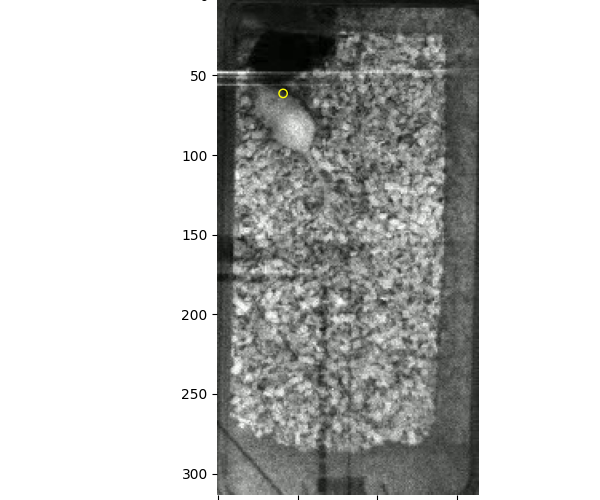

In [54]:
%matplotlib widget
kpms.noise_calibration(kpmoseq_dir, coordinates, confidences, overwrite = False, **config())

## Load data for training (same as for calibration)

In [4]:
from pathlib import PureWindowsPath

calib_video_dir = Path(kpmoseq_dir) / "calibration_videos"
calibration_files = np.load(Path(calib_video_dir) /"calibration_files.npy")

h5Dataset = Path("/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/analyzedVideos_unifiedDataset_DLC_singleAnimal_downsampled_10fps")

linuxPaths = []
for h5_path in calibration_files:
    path_str = h5_path
    fileName = PureWindowsPath(path_str).name

    h5 = next(h5Dataset.rglob(fileName))

    linuxPaths.append(str(h5))


In [5]:
kpms.update_config(kpmoseq_dir, fps = 10)

In [6]:
coordinates, confidences, bodyparts = kpms.load_keypoints(linuxPaths, "deeplabcut")

Loading keypoints:   0%|                        | 0/141 [00:00<?, ?it/s]

Loading keypoints: 100%|██████████████| 141/141 [00:04<00:00, 33.12it/s]


In [7]:
kpms.update_config(kpmoseq_dir, outlier_scale_factor=6.0)

coordinates, confidences = kpms.outlier_removal(
    coordinates,
    confidences,
    kpmoseq_dir,
    overwrite=False,
    **config()
)

In [8]:
data, metadata = kpms.format_data(coordinates, confidences, **config())

## Extracting the number of components from videography data that explain >= 90% of the variance in behavioral syllables

>=90.0% of variance exlained by 5 components.


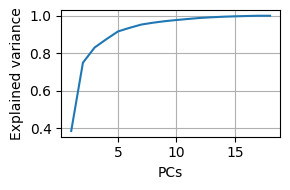

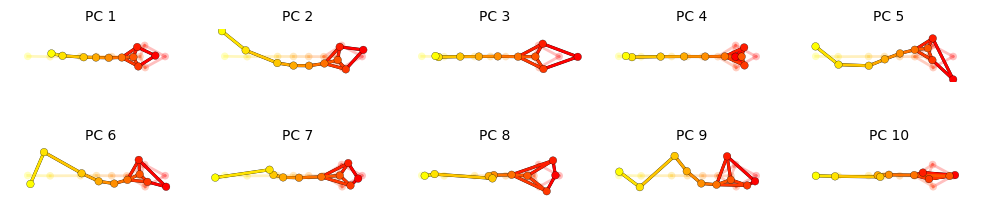

In [22]:
plt.close("all")
pca = kpms.fit_pca(**data, **config())
kpms.save_pca(pca, kpmoseq_dir)

kpms.print_dims_to_explain_variance(pca, 0.9)
kpms.plot_scree(pca, project_dir=kpmoseq_dir)
kpms.plot_pcs(pca, project_dir=kpmoseq_dir, **config())

In [23]:
kpms.update_config(kpmoseq_dir, latent_dim=5) # >= 90.0% of the variance is explained by 6 components

In [24]:
kpms.update_config(
    kpmoseq_dir,
    sigmasq_loc=kpms.estimate_sigmasq_loc(data["Y"], data["mask"], filter_size=config()["fps"])
)

## **Kappa scan**: Hyperparameter that that determines the rate of transitions between syllables. Higher values of kappa lead to longer syllables and smaller values lead to shorter syllables.

In [9]:
from jax_moseq.utils import set_mixed_map_iters

set_mixed_map_iters(6)

Fitting model with kappa=100.0
Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-100.0


 49%|█████████████████▏                 | 25/51 [00:54<00:49,  1.91s/it]

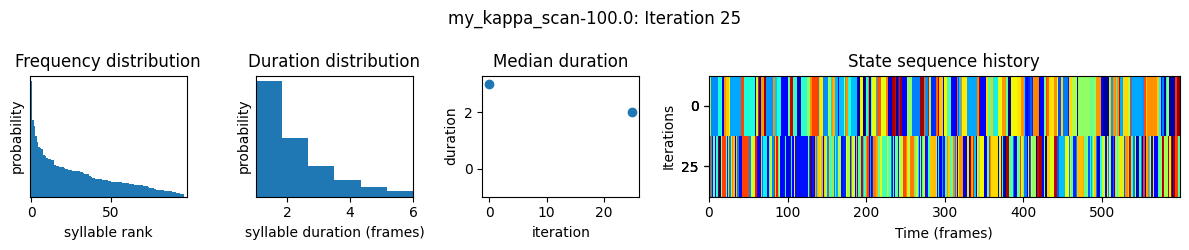

 98%|██████████████████████████████████▎| 50/51 [01:45<00:01,  1.96s/it]

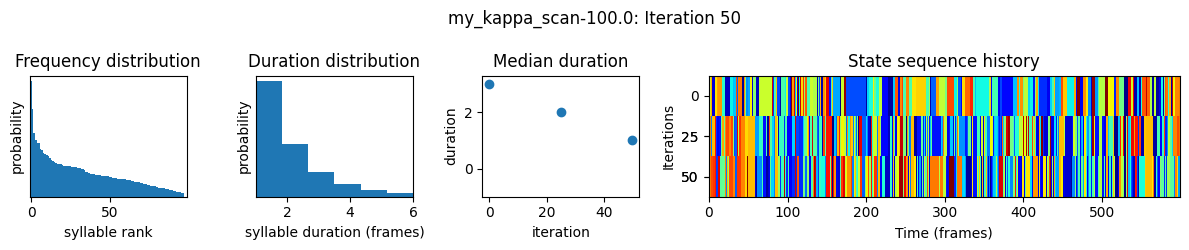

100%|███████████████████████████████████| 51/51 [01:48<00:00,  2.13s/it]


Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-100.0


 17%|█████▋                            | 25/151 [02:17<08:16,  3.94s/it]

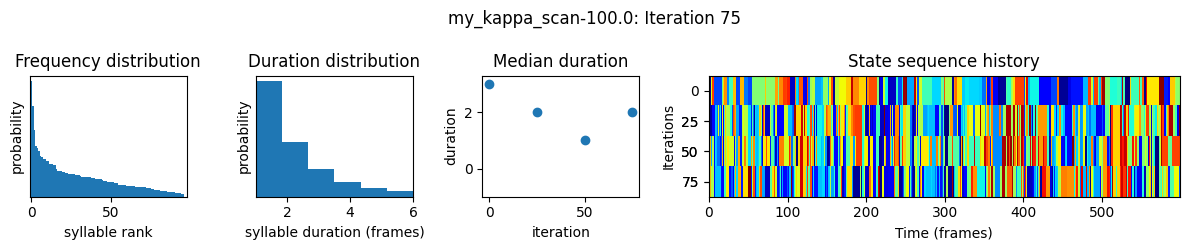

 33%|███████████▎                      | 50/151 [03:57<06:35,  3.92s/it]

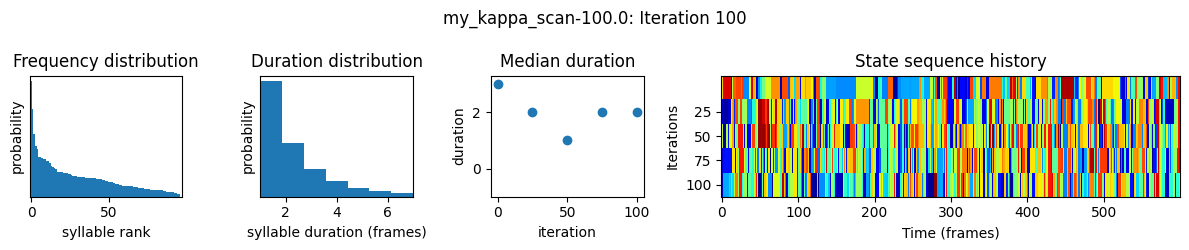

 50%|████████████████▉                 | 75/151 [05:36<04:57,  3.92s/it]

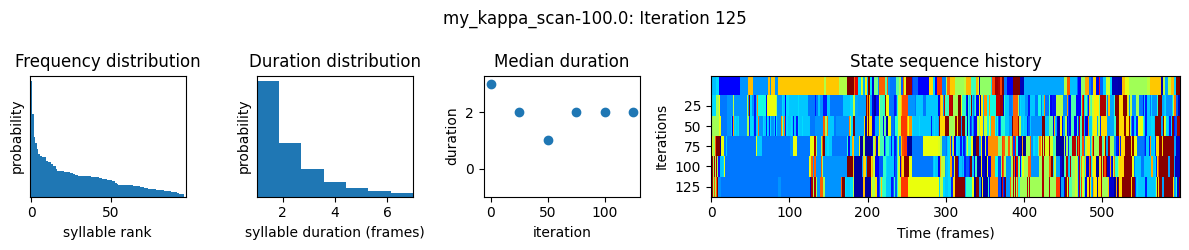

 66%|█████████████████████▊           | 100/151 [07:16<03:19,  3.91s/it]

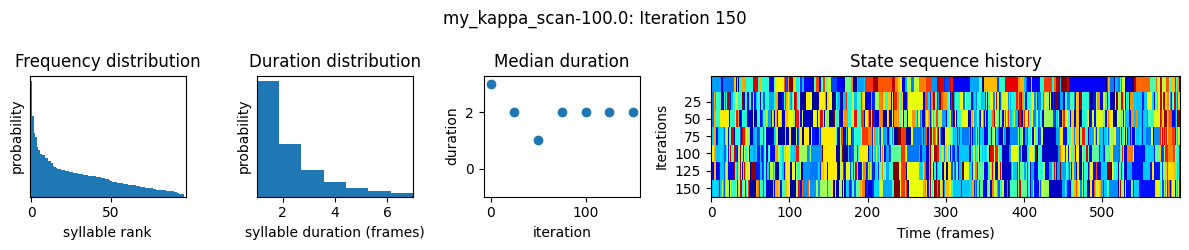

 83%|███████████████████████████▎     | 125/151 [08:56<01:41,  3.91s/it]

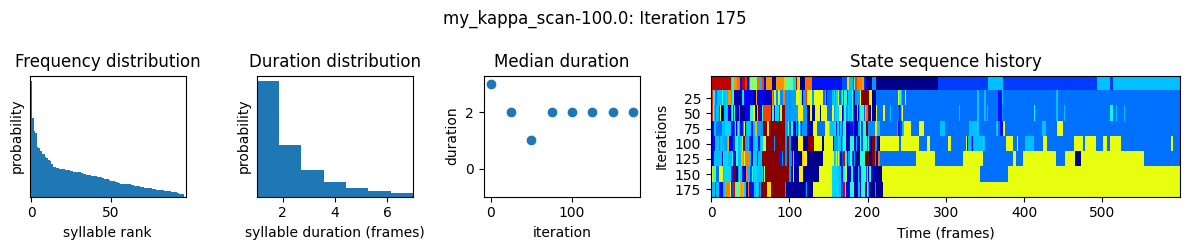

 99%|████████████████████████████████▊| 150/151 [10:35<00:03,  3.91s/it]

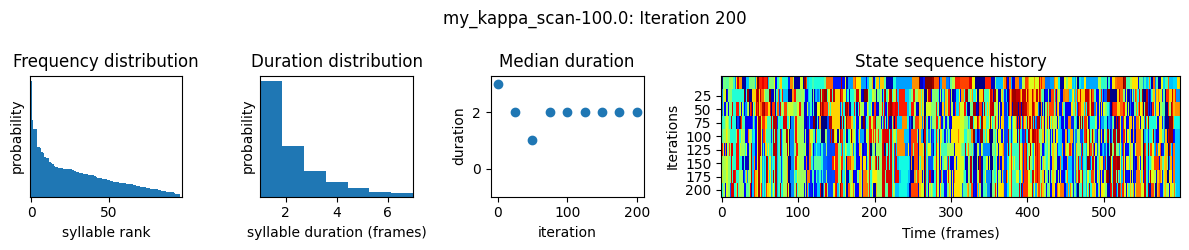

100%|█████████████████████████████████| 151/151 [10:41<00:00,  4.25s/it]


Fitting model with kappa=1000.0
Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-1000.0


 49%|█████████████████▏                 | 25/51 [00:47<00:49,  1.89s/it]

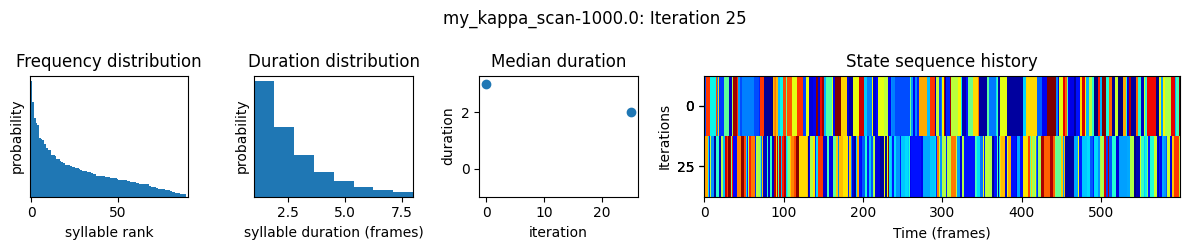

 98%|██████████████████████████████████▎| 50/51 [01:36<00:01,  1.89s/it]

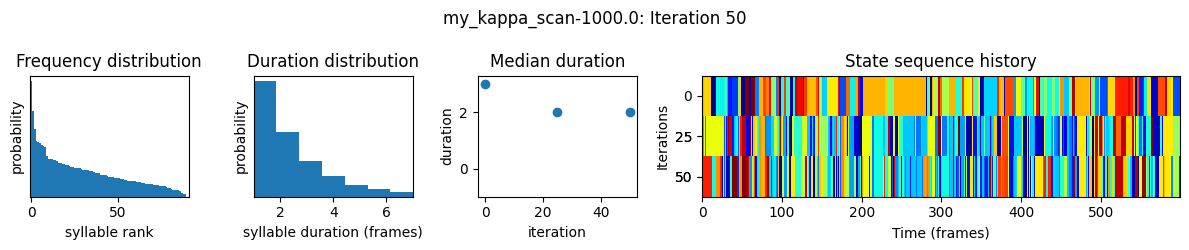

100%|███████████████████████████████████| 51/51 [01:39<00:00,  1.95s/it]


Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-1000.0


 17%|█████▋                            | 25/151 [01:37<08:12,  3.91s/it]

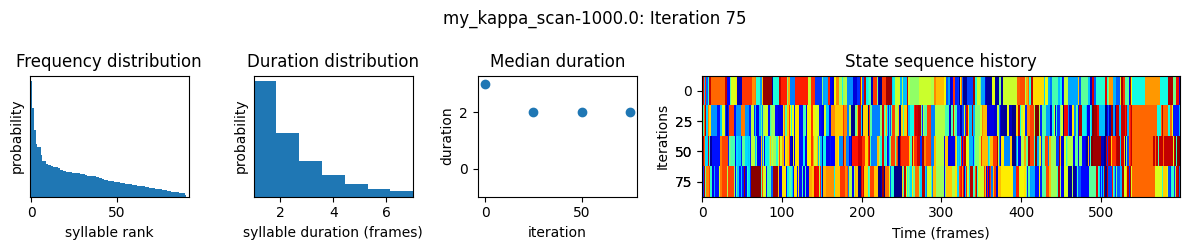

 33%|███████████▎                      | 50/151 [03:16<06:34,  3.91s/it]

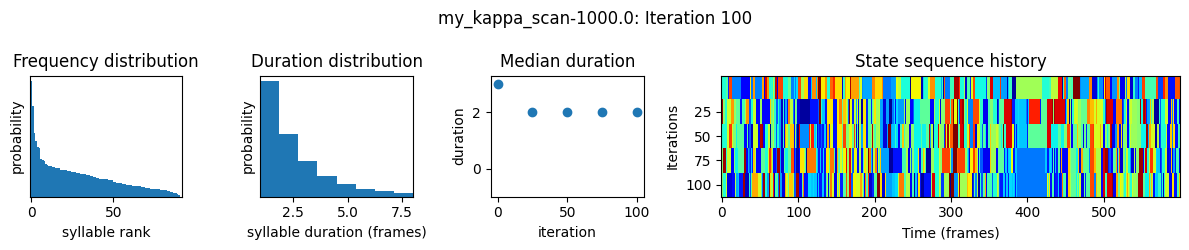

 50%|████████████████▉                 | 75/151 [04:56<04:57,  3.91s/it]

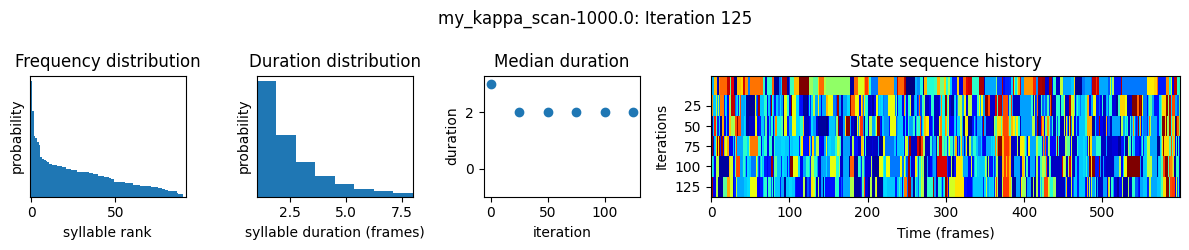

 66%|█████████████████████▊           | 100/151 [06:36<03:19,  3.90s/it]

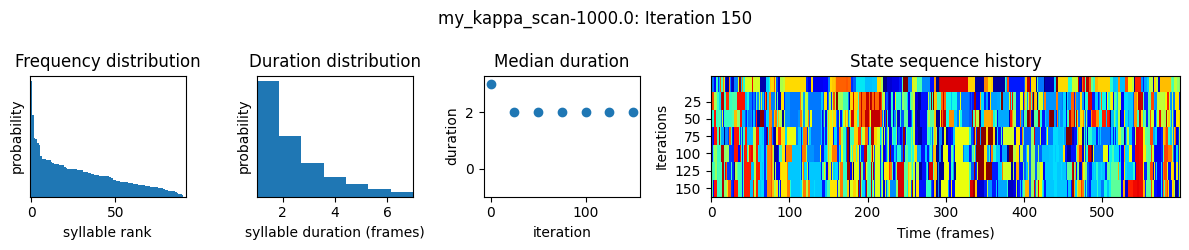

 83%|███████████████████████████▎     | 125/151 [08:16<01:42,  3.94s/it]

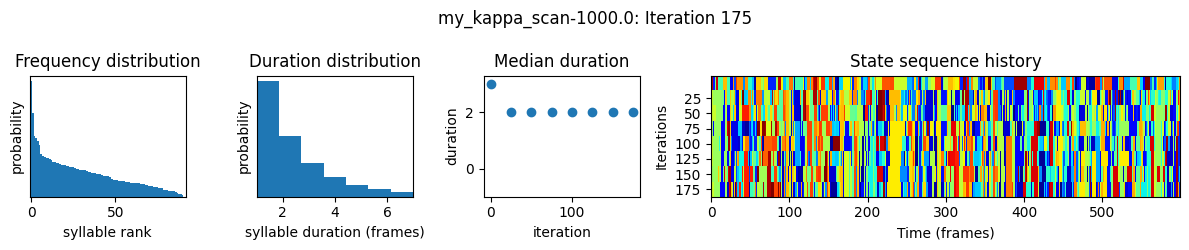

 99%|████████████████████████████████▊| 150/151 [09:56<00:03,  3.91s/it]

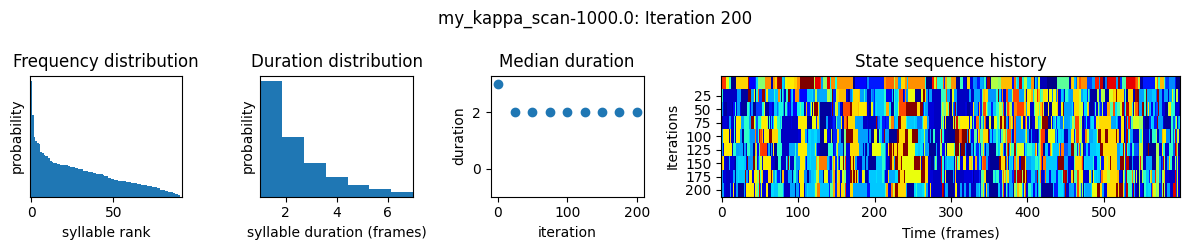

100%|█████████████████████████████████| 151/151 [10:02<00:00,  3.99s/it]


Fitting model with kappa=10000.0
Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-10000.0


 49%|█████████████████▏                 | 25/51 [00:47<00:49,  1.90s/it]

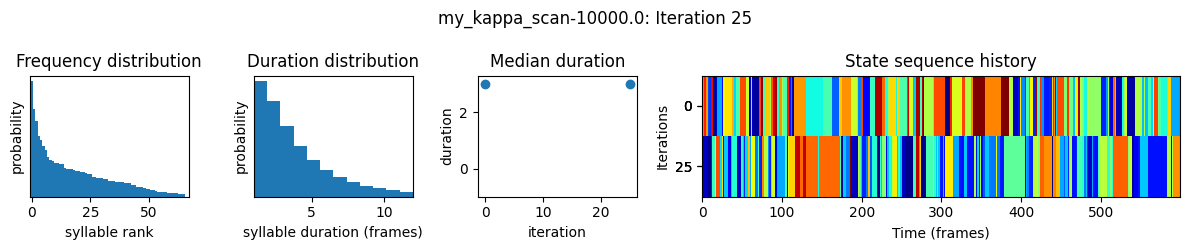

 98%|██████████████████████████████████▎| 50/51 [01:36<00:01,  1.90s/it]

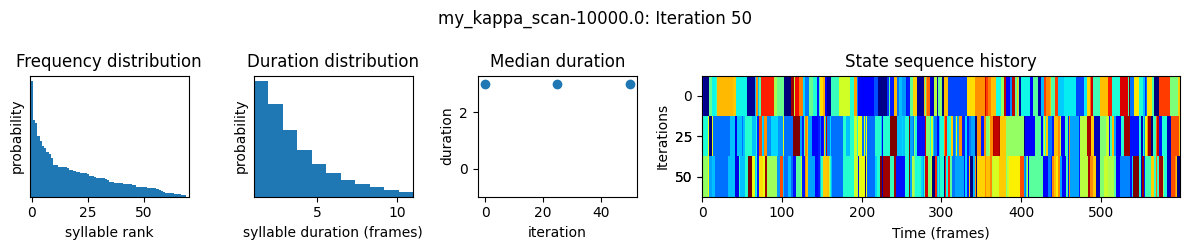

100%|███████████████████████████████████| 51/51 [01:40<00:00,  1.96s/it]


Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-10000.0


 17%|█████▋                            | 25/151 [01:37<08:13,  3.91s/it]

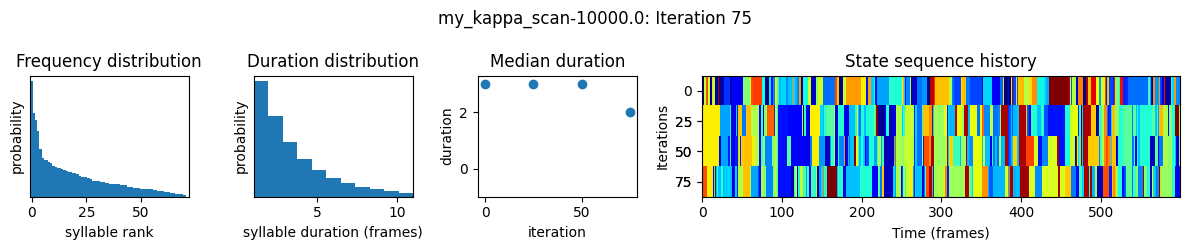

 33%|███████████▎                      | 50/151 [03:17<06:35,  3.91s/it]

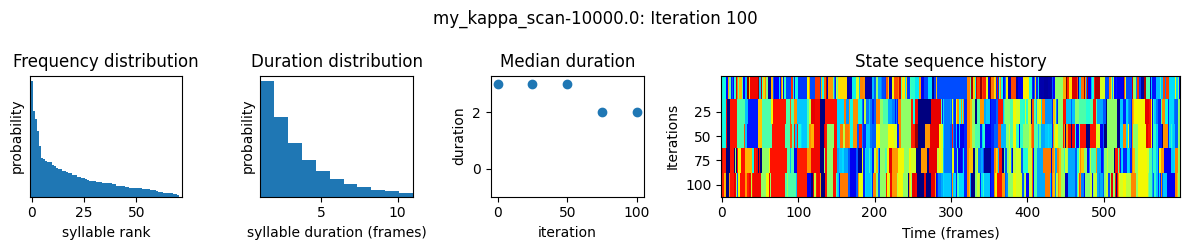

 50%|████████████████▉                 | 75/151 [04:56<04:57,  3.91s/it]

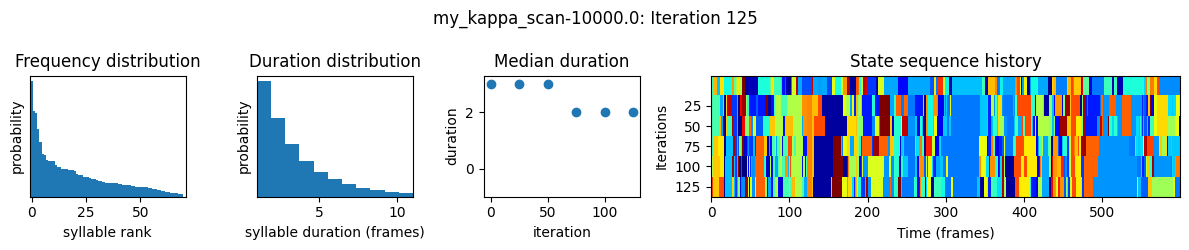

 66%|█████████████████████▊           | 100/151 [06:36<03:19,  3.91s/it]

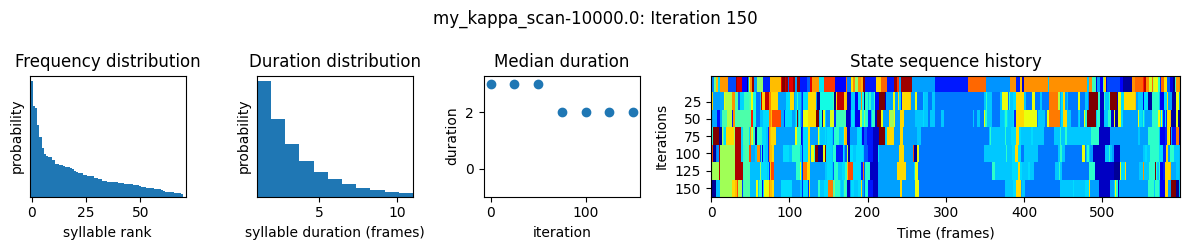

 83%|███████████████████████████▎     | 125/151 [08:15<01:41,  3.91s/it]

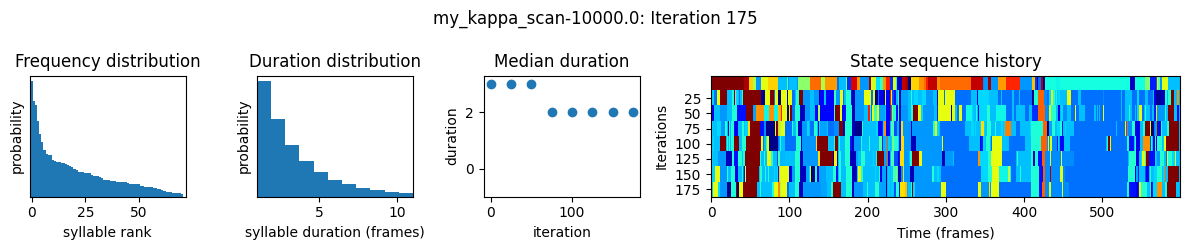

 99%|████████████████████████████████▊| 150/151 [09:55<00:03,  3.92s/it]

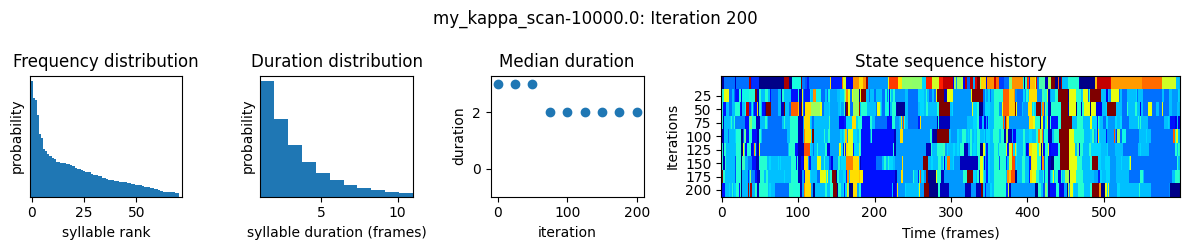

100%|█████████████████████████████████| 151/151 [10:01<00:00,  3.98s/it]


Fitting model with kappa=100000.0
Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-100000.0


 49%|█████████████████▏                 | 25/51 [00:47<00:49,  1.89s/it]

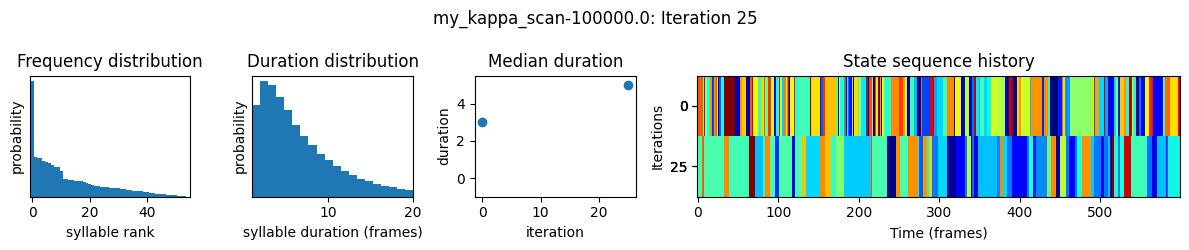

 98%|██████████████████████████████████▎| 50/51 [01:36<00:01,  1.90s/it]

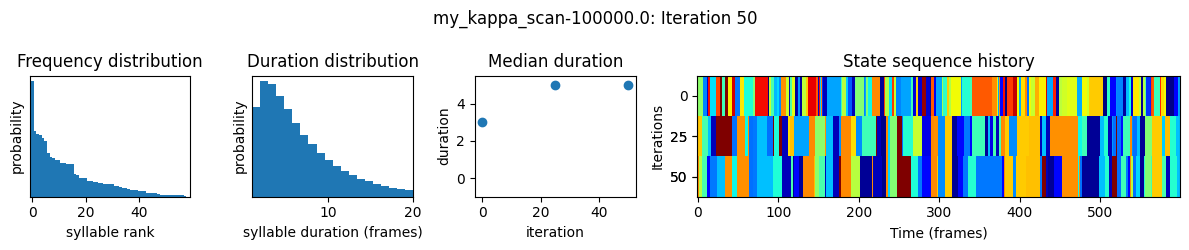

100%|███████████████████████████████████| 51/51 [01:39<00:00,  1.96s/it]


Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-100000.0


 17%|█████▋                            | 25/151 [01:37<08:12,  3.91s/it]

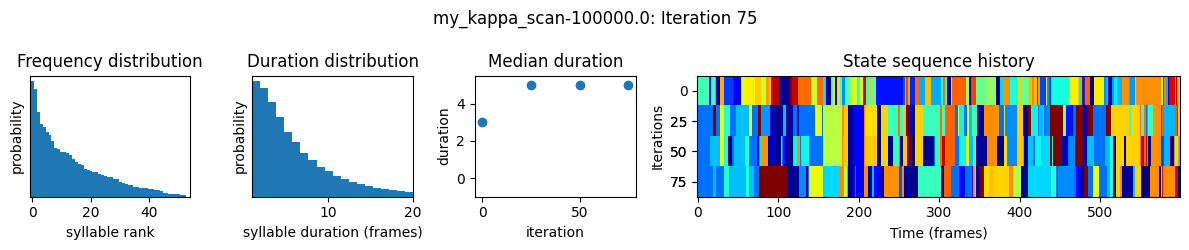

 33%|███████████▎                      | 50/151 [03:16<06:34,  3.90s/it]

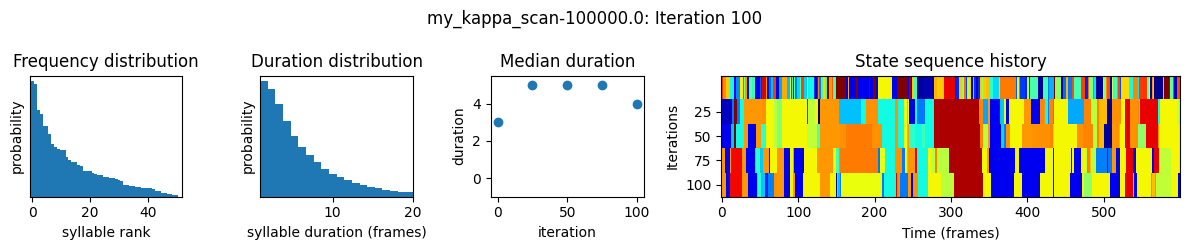

 50%|████████████████▉                 | 75/151 [04:56<04:56,  3.91s/it]

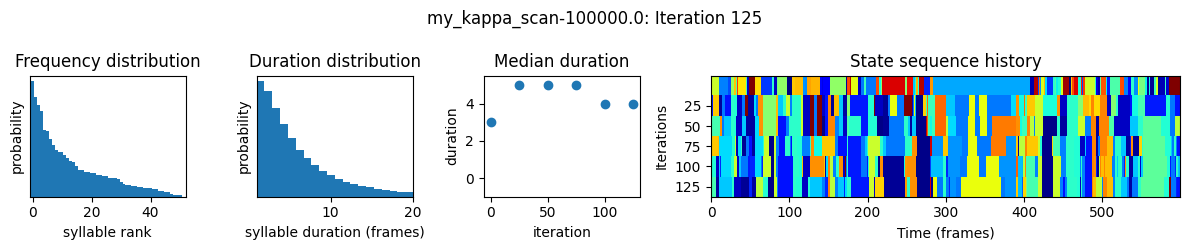

 66%|█████████████████████▊           | 100/151 [06:35<03:19,  3.91s/it]

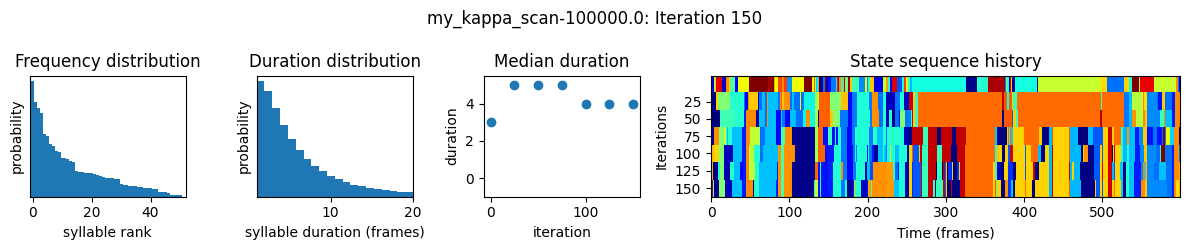

 83%|███████████████████████████▎     | 125/151 [08:15<01:42,  3.93s/it]

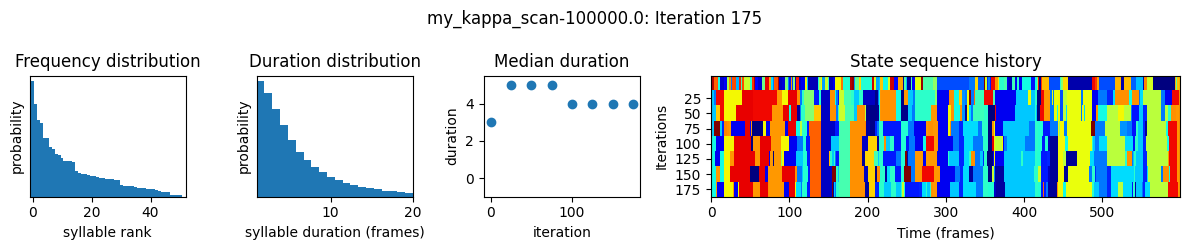

 99%|████████████████████████████████▊| 150/151 [09:55<00:03,  3.91s/it]

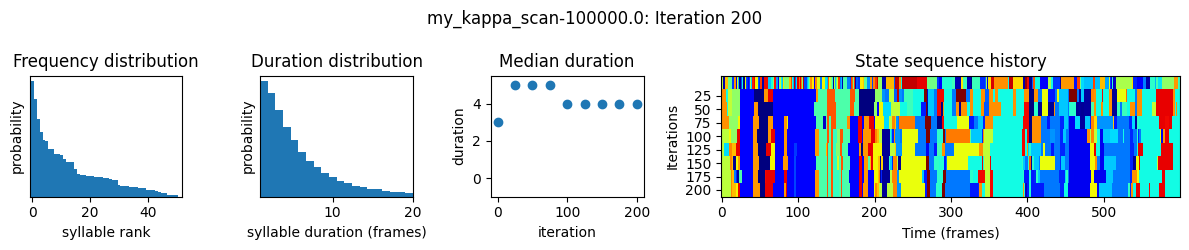

100%|█████████████████████████████████| 151/151 [10:01<00:00,  3.98s/it]


Fitting model with kappa=1000000.0
Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-1000000.0


 49%|█████████████████▏                 | 25/51 [00:47<00:49,  1.90s/it]

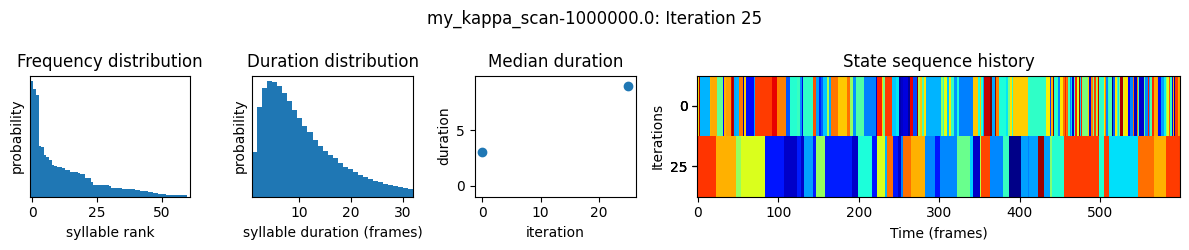

 98%|██████████████████████████████████▎| 50/51 [01:36<00:01,  1.90s/it]

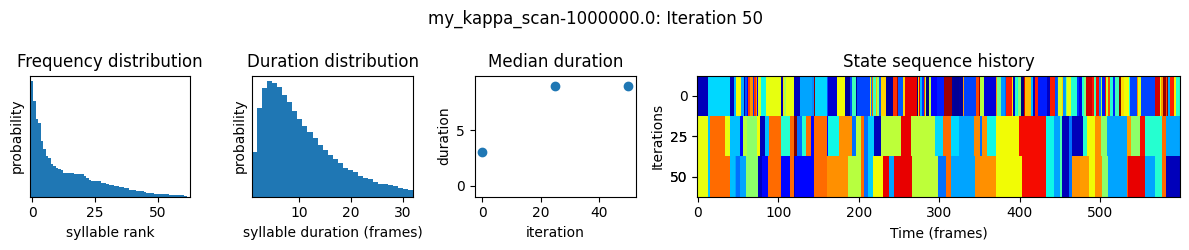

100%|███████████████████████████████████| 51/51 [01:39<00:00,  1.96s/it]


Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-1000000.0


 17%|█████▋                            | 25/151 [01:37<08:14,  3.93s/it]

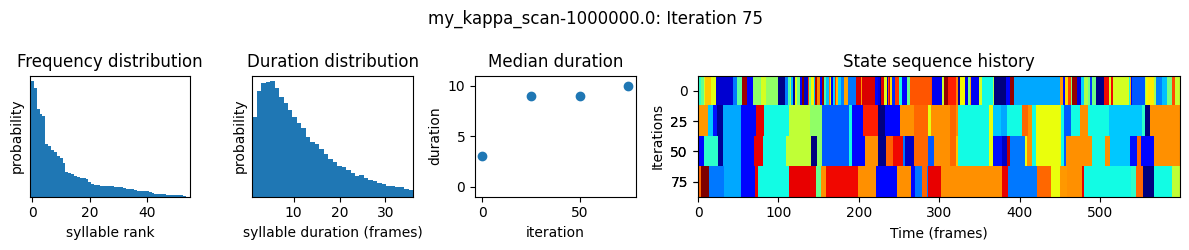

 33%|███████████▎                      | 50/151 [03:17<06:34,  3.91s/it]

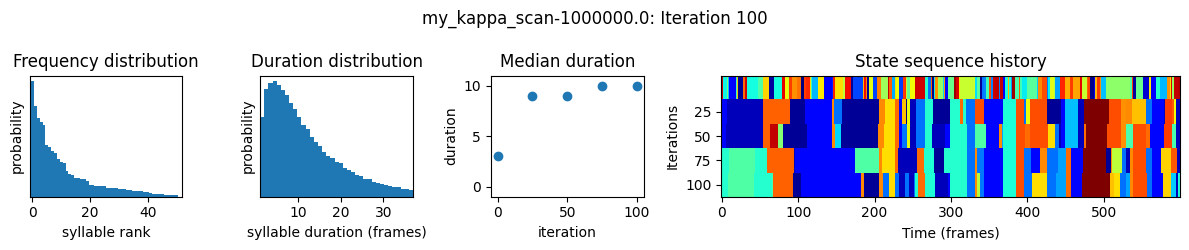

 50%|████████████████▉                 | 75/151 [04:56<04:57,  3.91s/it]

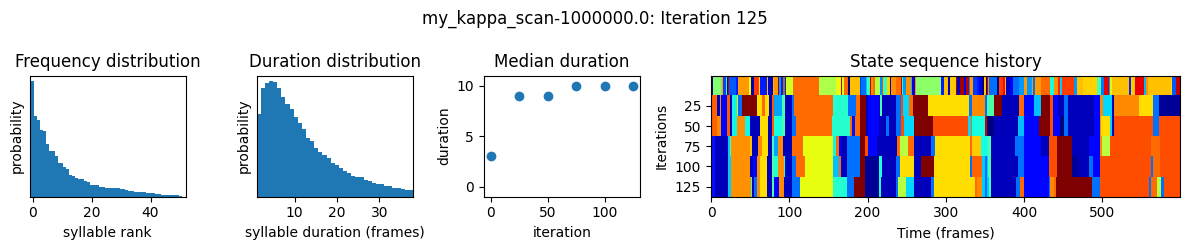

 66%|█████████████████████▊           | 100/151 [06:36<03:19,  3.91s/it]

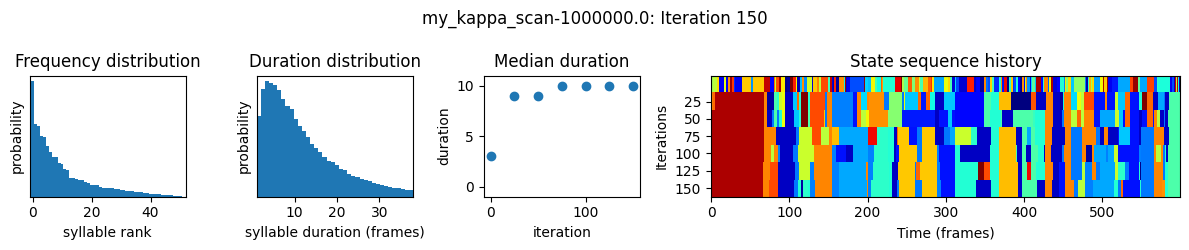

 83%|███████████████████████████▎     | 125/151 [08:15<01:41,  3.91s/it]

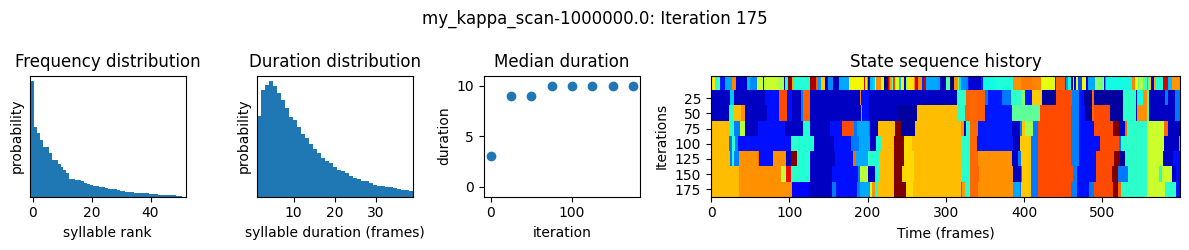

 99%|████████████████████████████████▊| 150/151 [09:55<00:03,  3.91s/it]

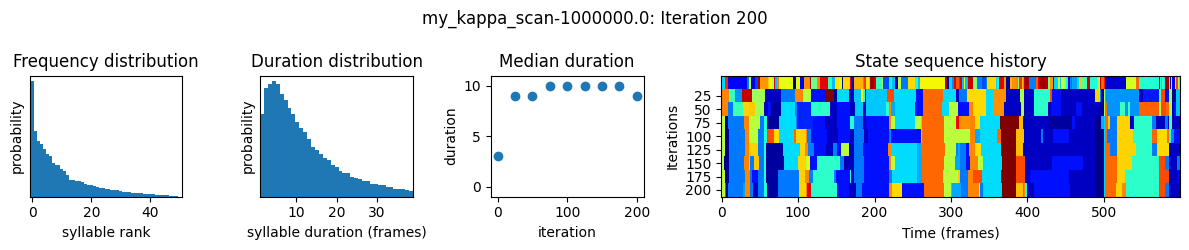

100%|█████████████████████████████████| 151/151 [10:01<00:00,  3.98s/it]


Fitting model with kappa=10000000.0
Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-10000000.0


 49%|█████████████████▏                 | 25/51 [00:47<00:49,  1.91s/it]

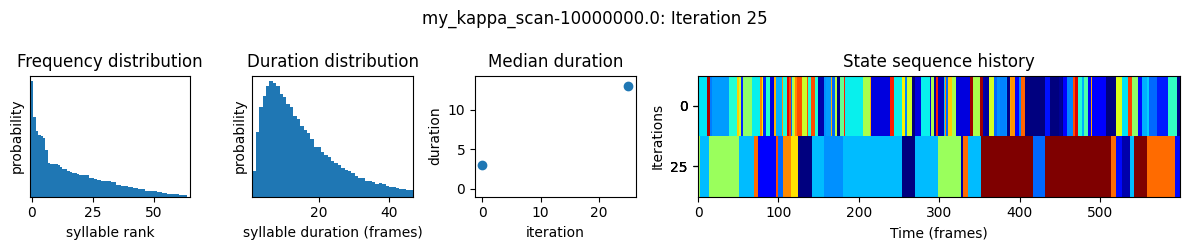

 98%|██████████████████████████████████▎| 50/51 [01:36<00:01,  1.91s/it]

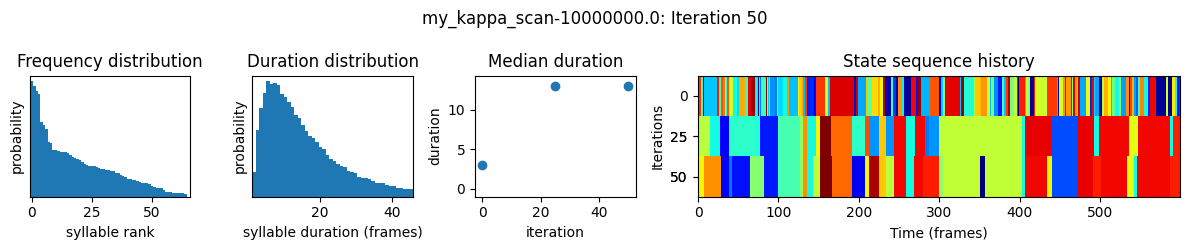

100%|███████████████████████████████████| 51/51 [01:40<00:00,  1.97s/it]


Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-10000000.0


 17%|█████▋                            | 25/151 [01:37<08:13,  3.91s/it]

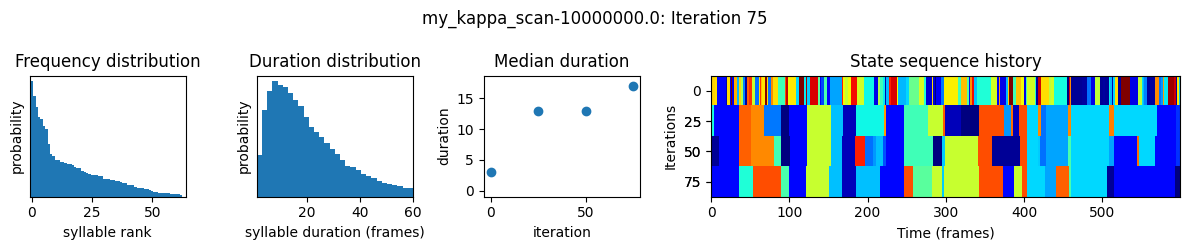

 33%|███████████▎                      | 50/151 [03:18<06:40,  3.97s/it]

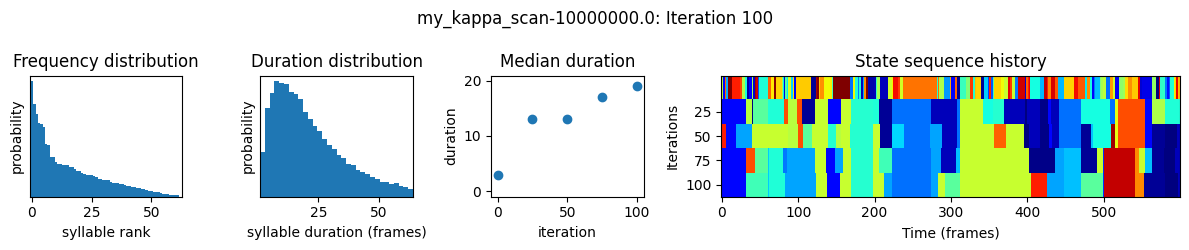

 50%|████████████████▉                 | 75/151 [04:59<05:01,  3.96s/it]

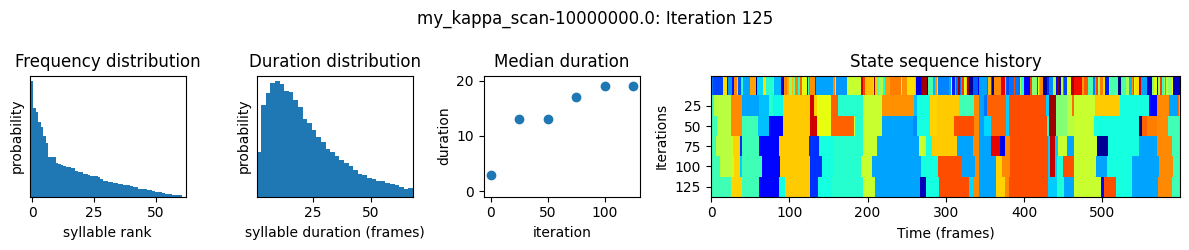

 66%|█████████████████████▊           | 100/151 [06:39<03:22,  3.96s/it]

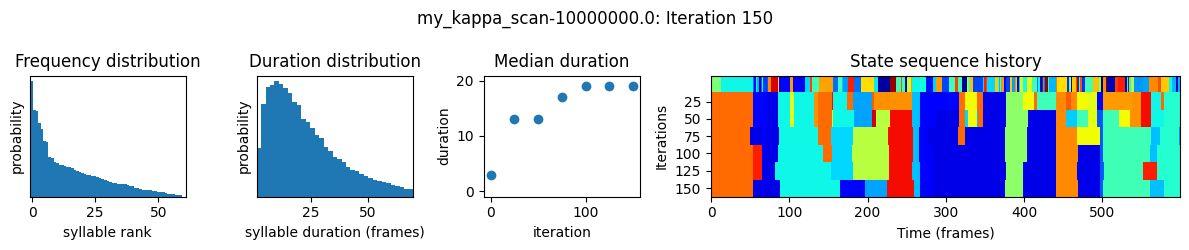

 83%|███████████████████████████▎     | 125/151 [08:21<01:43,  3.98s/it]

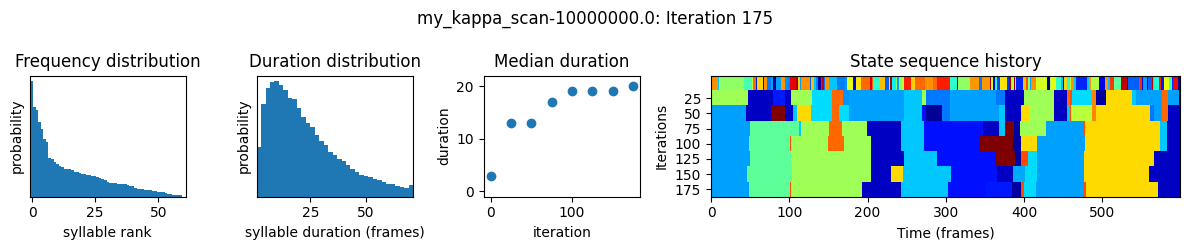

 99%|████████████████████████████████▊| 150/151 [10:02<00:03,  3.98s/it]

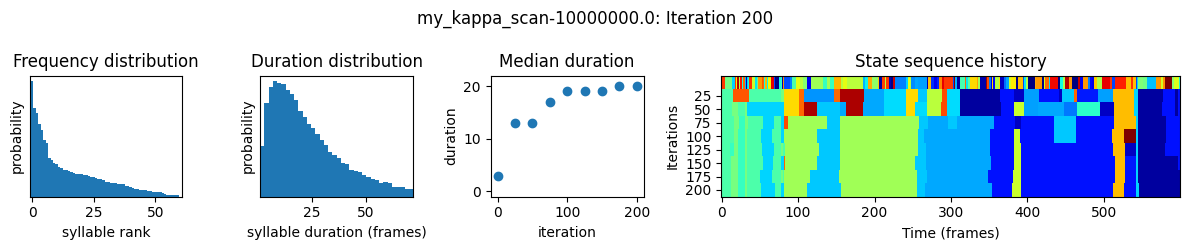

100%|█████████████████████████████████| 151/151 [10:09<00:00,  4.03s/it]


Fitting model with kappa=100000000.0
Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-100000000.0


 49%|█████████████████▏                 | 25/51 [00:47<00:49,  1.92s/it]

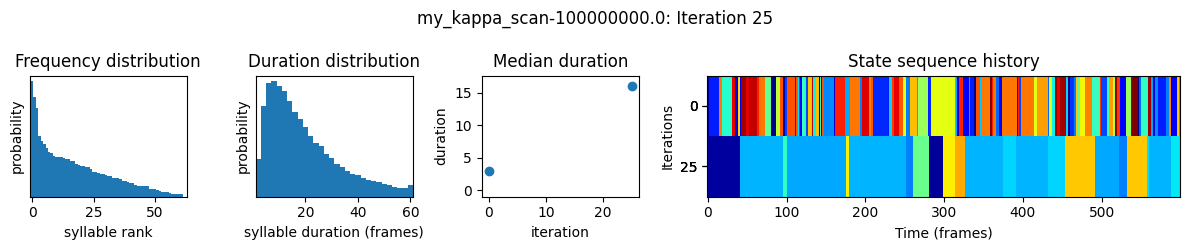

 98%|██████████████████████████████████▎| 50/51 [01:37<00:01,  1.91s/it]

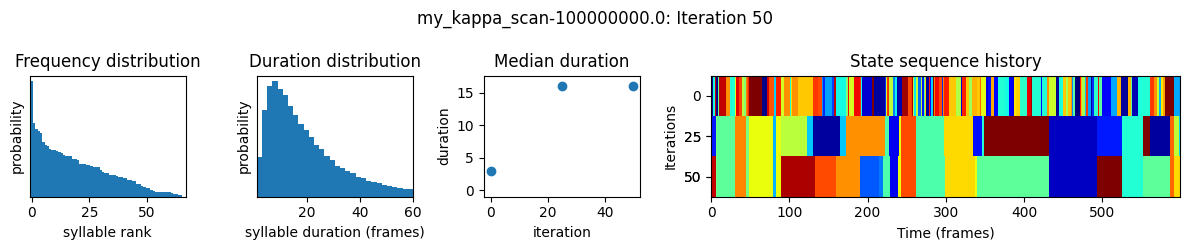

100%|███████████████████████████████████| 51/51 [01:40<00:00,  1.98s/it]


Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-100000000.0


 17%|█████▋                            | 25/151 [01:37<08:13,  3.92s/it]

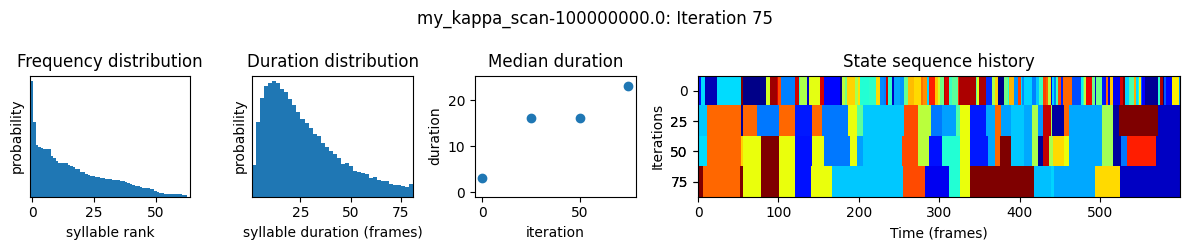

 33%|███████████▎                      | 50/151 [03:17<06:35,  3.92s/it]

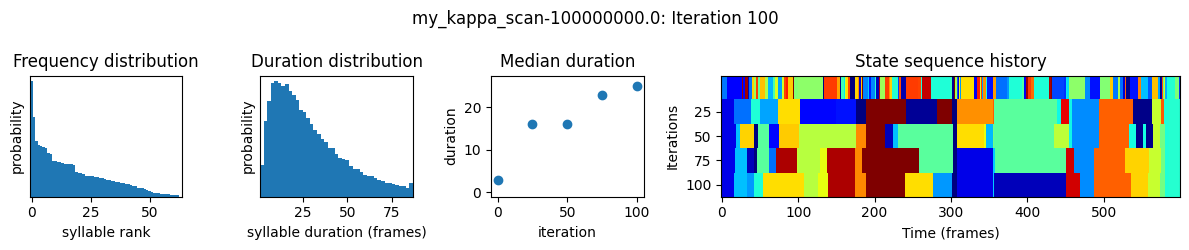

 50%|████████████████▉                 | 75/151 [04:57<05:01,  3.97s/it]

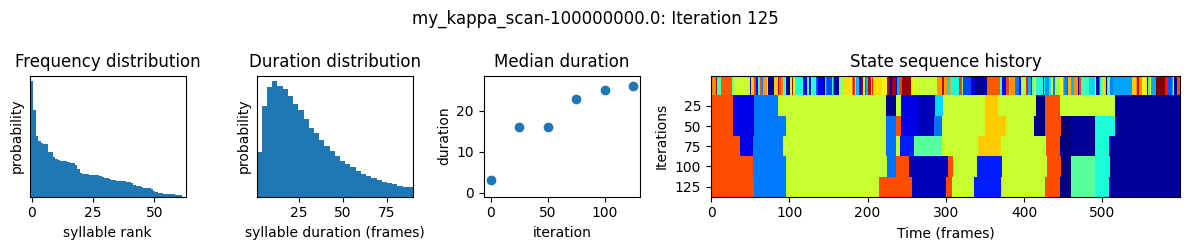

 66%|█████████████████████▊           | 100/151 [06:38<03:22,  3.97s/it]

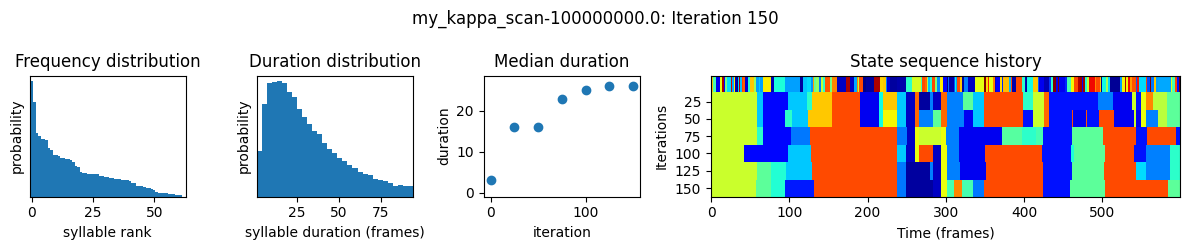

 83%|███████████████████████████▎     | 125/151 [08:19<01:43,  3.97s/it]

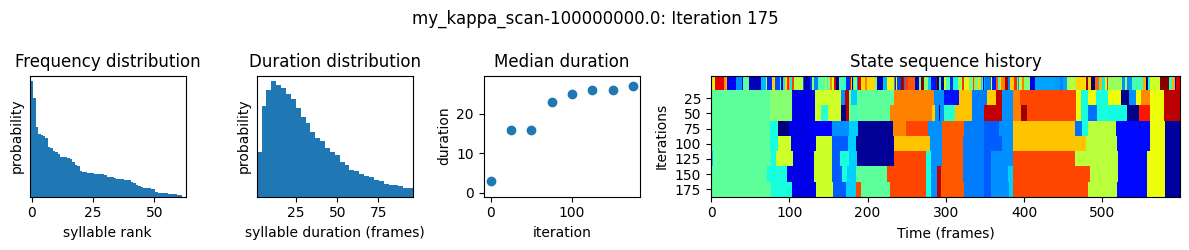

 99%|████████████████████████████████▊| 150/151 [10:00<00:03,  3.97s/it]

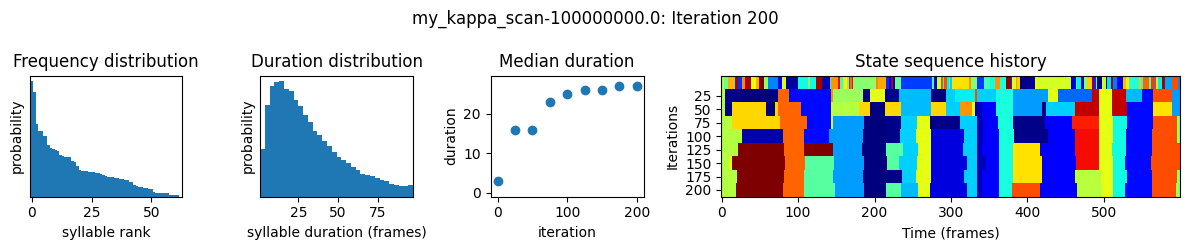

100%|█████████████████████████████████| 151/151 [10:06<00:00,  4.02s/it]


Fitting model with kappa=1000000000.0
Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-1000000000.0


 49%|█████████████████▏                 | 25/51 [00:48<00:50,  1.95s/it]

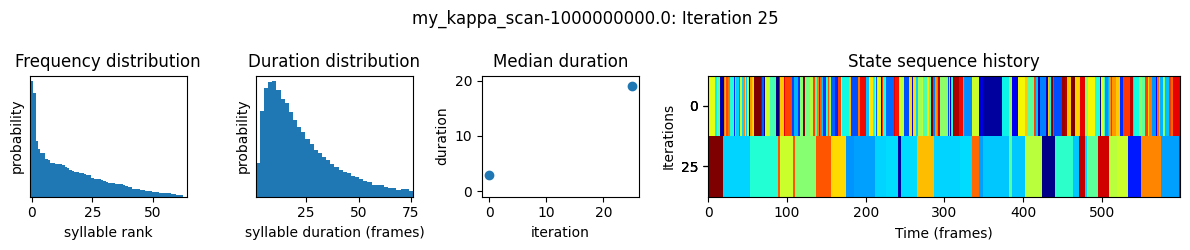

 98%|██████████████████████████████████▎| 50/51 [01:39<00:01,  1.95s/it]

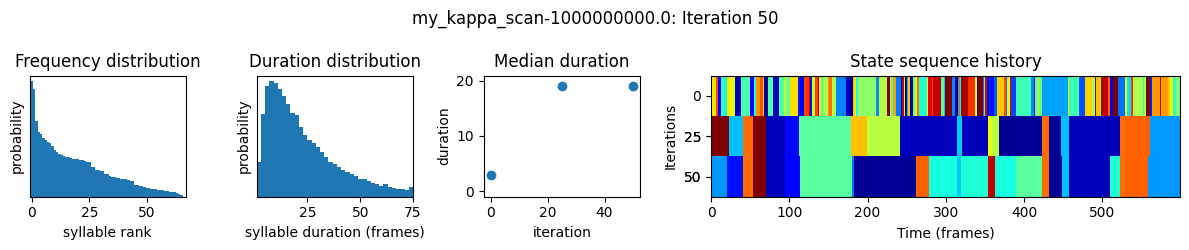

100%|███████████████████████████████████| 51/51 [01:42<00:00,  2.01s/it]


Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-1000000000.0


 17%|█████▋                            | 25/151 [01:37<08:12,  3.91s/it]

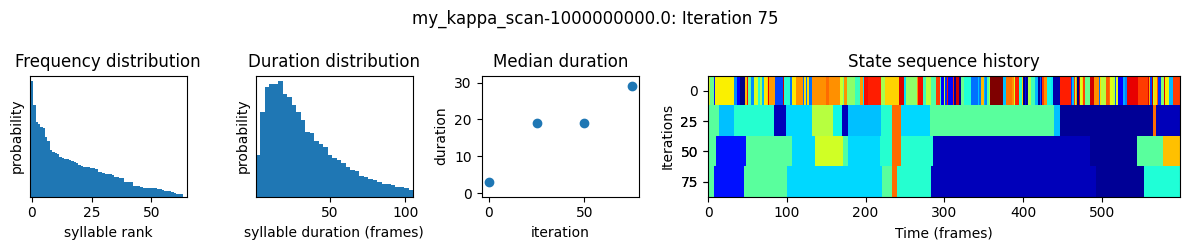

 33%|███████████▎                      | 50/151 [03:17<06:34,  3.91s/it]

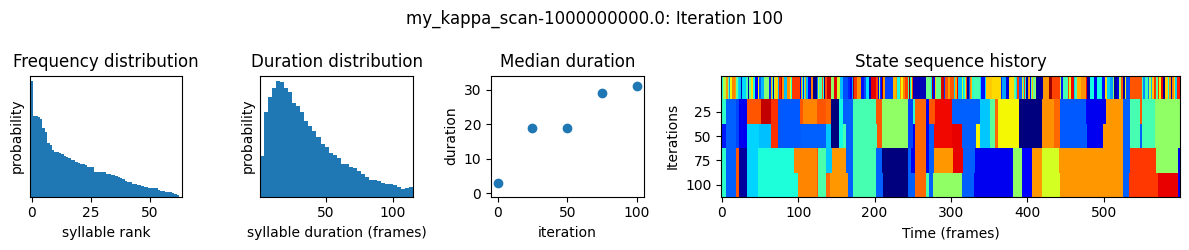

 50%|████████████████▉                 | 75/151 [04:56<05:01,  3.96s/it]

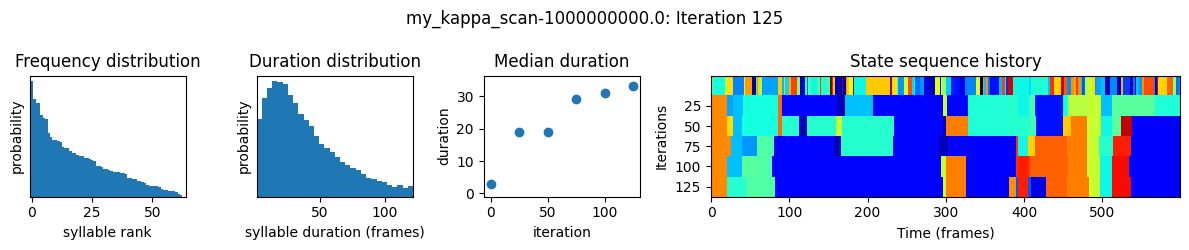

 66%|█████████████████████▊           | 100/151 [06:37<03:21,  3.96s/it]

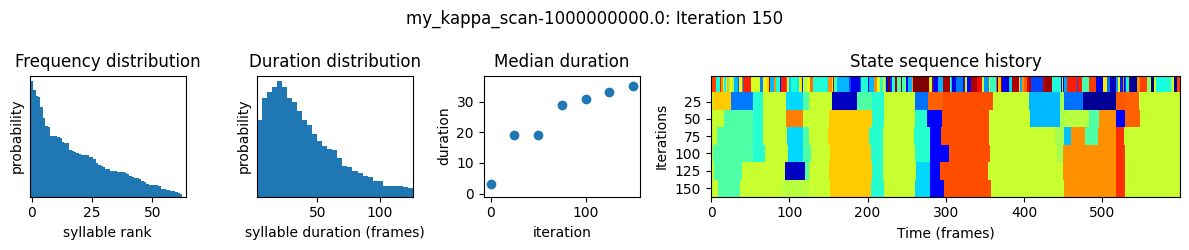

 83%|███████████████████████████▎     | 125/151 [08:18<01:43,  3.96s/it]

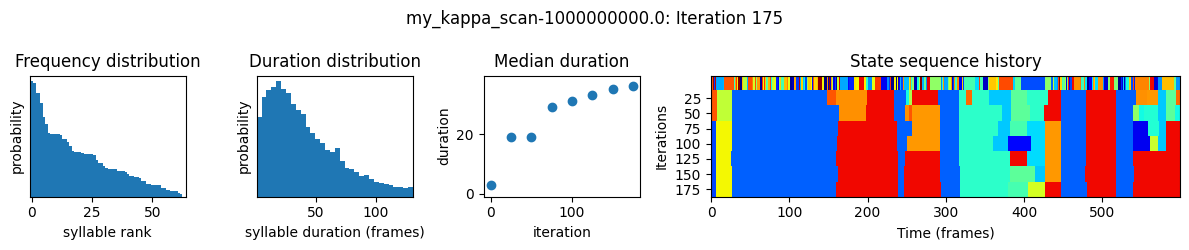

 99%|████████████████████████████████▊| 150/151 [09:59<00:03,  3.96s/it]

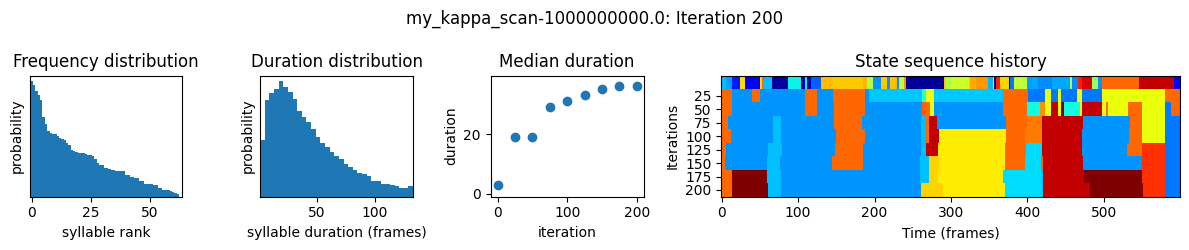

100%|█████████████████████████████████| 151/151 [10:05<00:00,  4.01s/it]


Fitting model with kappa=10000000000.0
Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-10000000000.0


 49%|█████████████████▏                 | 25/51 [00:47<00:49,  1.91s/it]

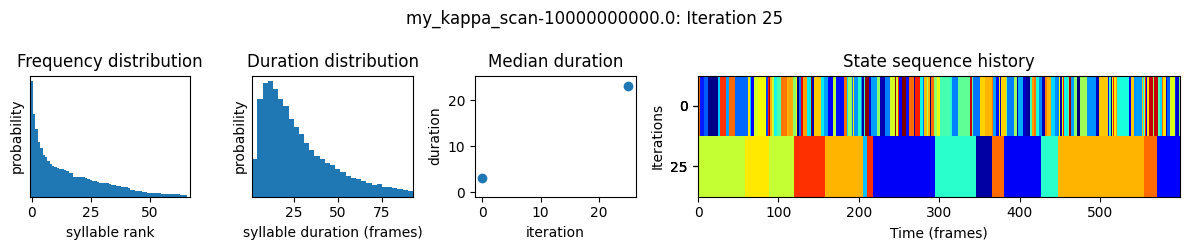

 98%|██████████████████████████████████▎| 50/51 [01:37<00:01,  1.91s/it]

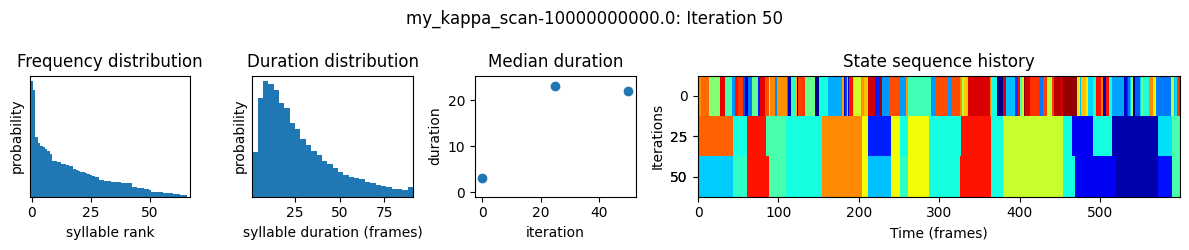

100%|███████████████████████████████████| 51/51 [01:41<00:00,  1.98s/it]


Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/my_kappa_scan-10000000000.0


 17%|█████▋                            | 25/151 [01:37<08:14,  3.92s/it]

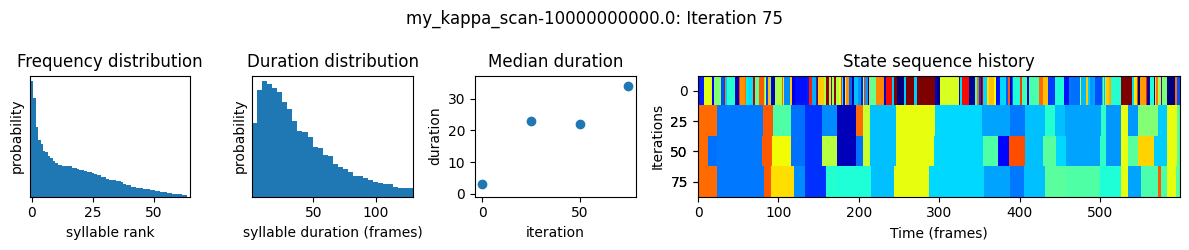

 33%|███████████▎                      | 50/151 [03:17<06:35,  3.91s/it]

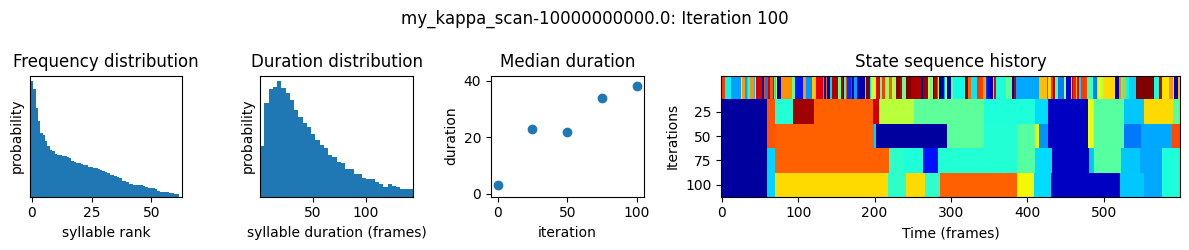

 50%|████████████████▉                 | 75/151 [04:56<04:57,  3.91s/it]

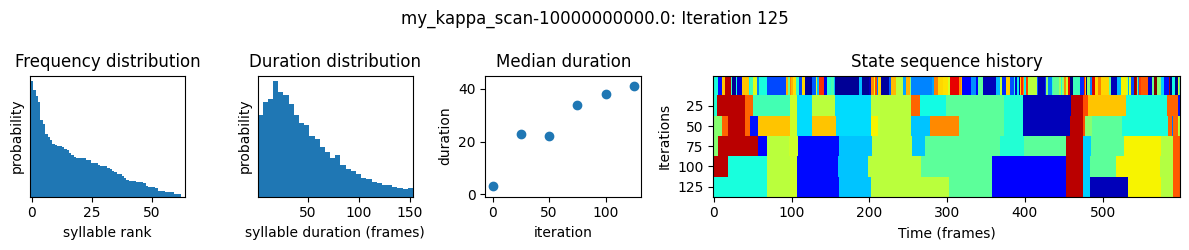

 66%|█████████████████████▊           | 100/151 [06:36<03:19,  3.92s/it]

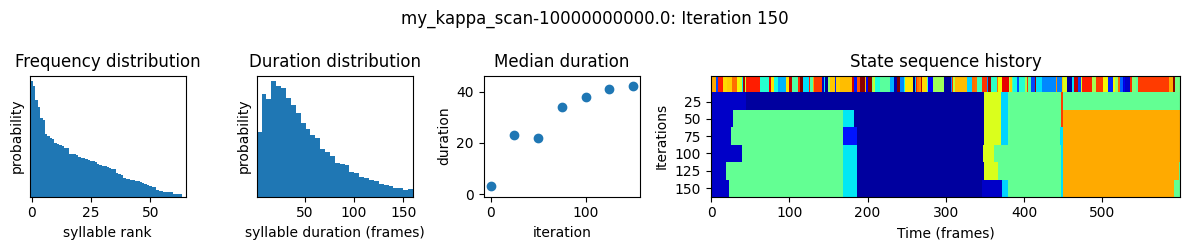

 83%|███████████████████████████▎     | 125/151 [08:16<01:41,  3.92s/it]

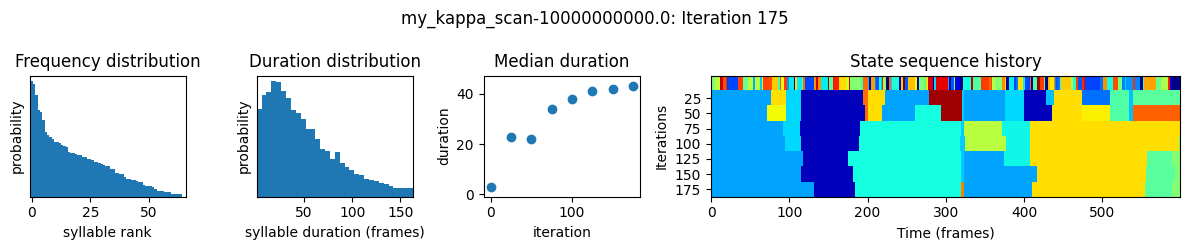

 99%|████████████████████████████████▊| 150/151 [09:55<00:03,  3.90s/it]

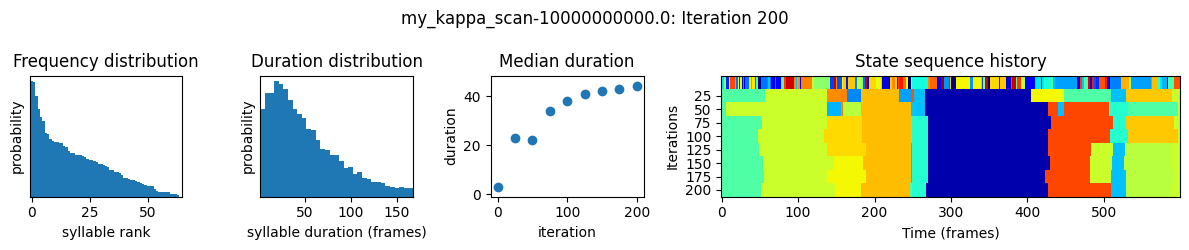

Loading checkpoints: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:03<00:00,  2.38it/s]


(<Figure size 800x250 with 2 Axes>,
 array([ 2.,  2.,  2.,  4.,  9., 20., 27., 36., 44.]))

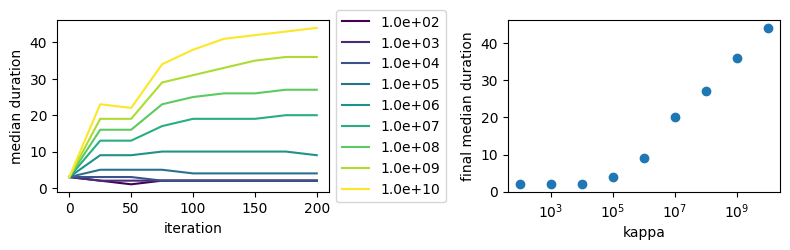

In [18]:
kappas = np.logspace(2,10,9)
decrease_kappa_factor = 10
num_ar_iters = 50
num_full_iters = 200

prefix = 'my_kappa_scan'

for kappa in kappas:
    print(f"Fitting model with kappa={kappa}")
    model_name = f'{prefix}-{kappa}'
    model = kpms.init_model(data, pca=pca, **config())

    # stage 1: fit the model with AR only
    model = kpms.update_hypparams(model, kappa=kappa)
    model = kpms.fit_model(
        model,
        data,
        metadata,
        kpmoseq_dir,
        model_name,
        ar_only=True,
        num_iters=num_ar_iters,
        parallel_message_passing=True,
        save_every_n_iters=25
    )[0];

    # stage 2: fit the full model
    model = kpms.update_hypparams(model, kappa=kappa/decrease_kappa_factor)
    kpms.fit_model(
        model,
        data,
        metadata,
        kpmoseq_dir,
        model_name,
        ar_only=False,
        start_iter=num_ar_iters,
        num_iters=num_full_iters,
        parallel_message_passing=True,
        save_every_n_iters=25
    );

kpms.plot_kappa_scan(kappas, kpmoseq_dir, prefix)

Models:  [Path('/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_KPMS_Resident/my_kappa_scan-100.0'), Path('/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_KPMS_Resident/my_kappa_scan-1000.0'), Path('/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_KPMS_Resident/my_kappa_scan-10000.0'), Path('/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_KPMS_Resident/my_kappa_scan-100000.0'), Path('/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_KPMS_Resident/my_kappa_scan-1000000.0'), Path('/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_KPMS_Resident/my_kappa_scan-10000000.0'), Path('/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DL

100%|█████████████████████████████████████| 9/9 [01:54<00:00, 12.68s/it]


Best model: /proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_KPMS_Resident/my_kappa_scan-10000.0


(<Figure size 400x350 with 1 Axes>, <Axes: ylabel='EML score'>)

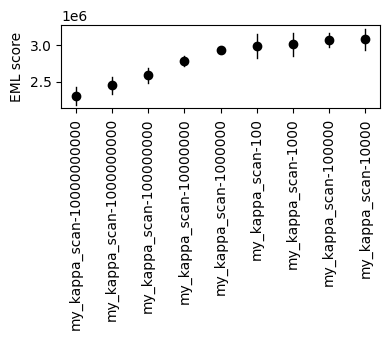

In [27]:
model_names = [f for f in Path(kpmoseq_dir).rglob(f"*{prefix}*")]
print("Models: ", model_names)

eml_scores, eml_std_errs = kpms.expected_marginal_likelihoods(kpmoseq_dir, model_names)
best_model = model_names[np.argmax(eml_scores)]
print(f"\nBest model: {best_model}")

kpms.plot_eml_scores(eml_scores, eml_std_errs, [str(Path(f).stem) for f in model_names])

## Train more iterations with best models

Outputs will be saved to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/fullModel_100000.0


  8%|██▊                               | 25/301 [01:42<18:46,  4.08s/it]

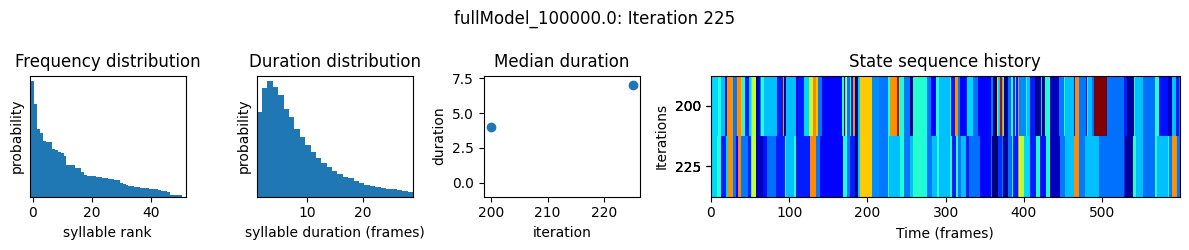

 17%|█████▋                            | 50/301 [03:26<17:07,  4.09s/it]

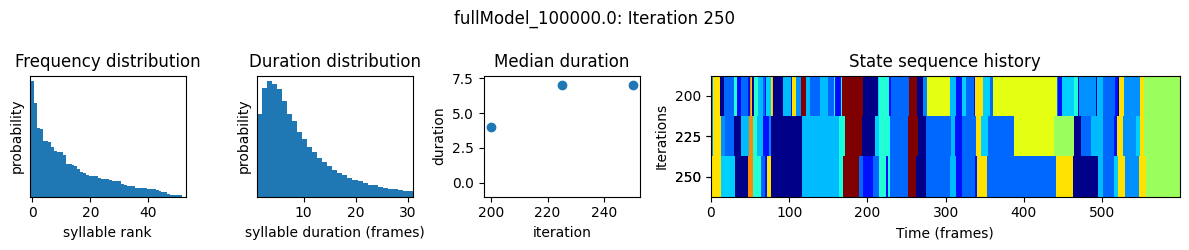

 25%|████████▍                         | 75/301 [05:08<15:09,  4.02s/it]

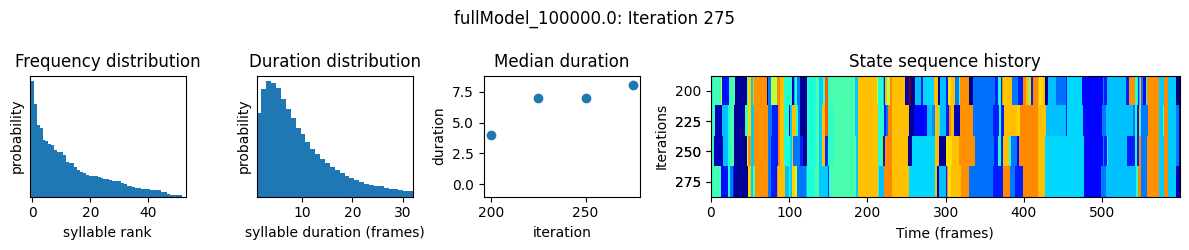

 33%|██████████▉                      | 100/301 [06:50<13:28,  4.02s/it]

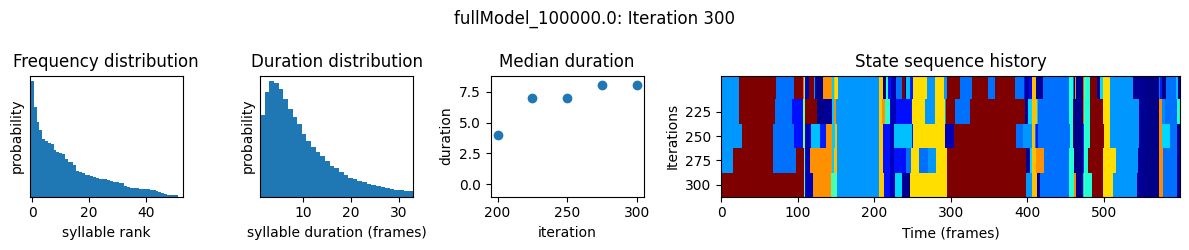

 42%|█████████████▋                   | 125/301 [08:32<11:48,  4.03s/it]

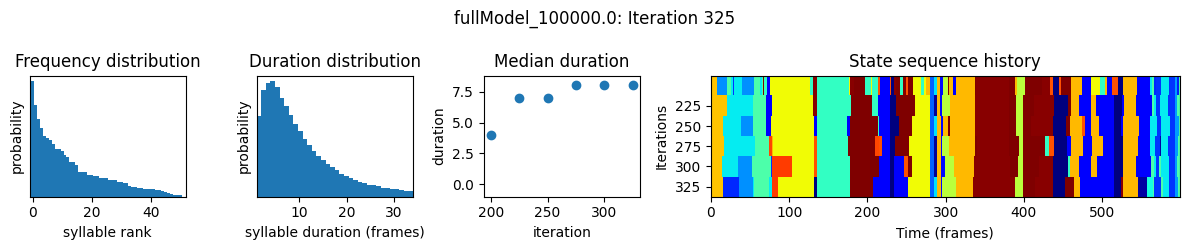

 50%|████████████████▍                | 150/301 [10:15<10:06,  4.02s/it]

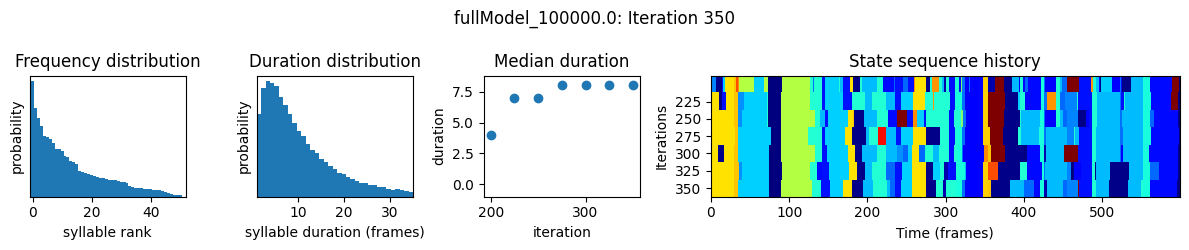

 58%|███████████████████▏             | 175/301 [11:57<08:26,  4.02s/it]

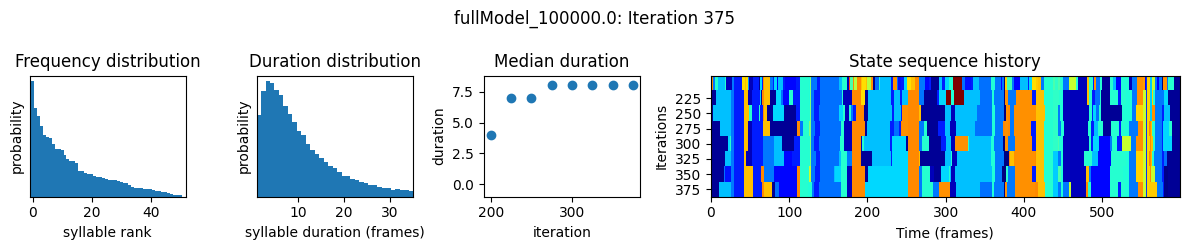

 66%|█████████████████████▉           | 200/301 [13:39<06:45,  4.02s/it]

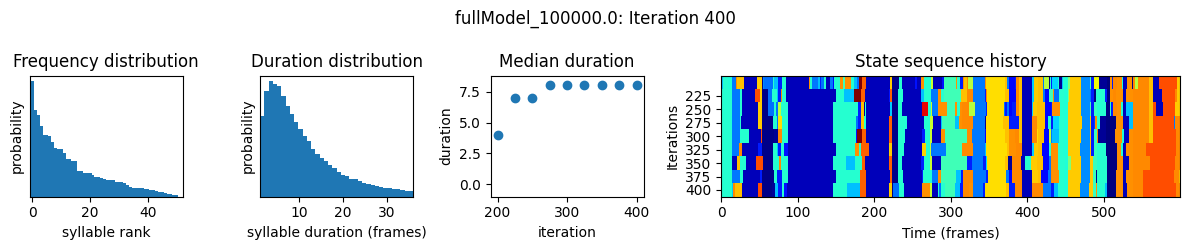

 75%|████████████████████████▋        | 225/301 [15:22<05:06,  4.03s/it]

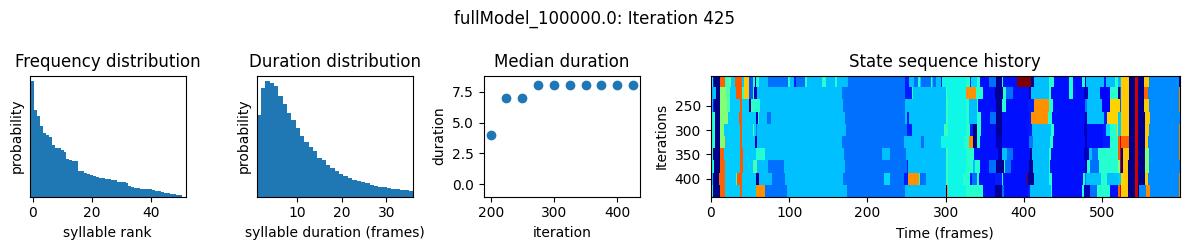

 83%|███████████████████████████▍     | 250/301 [17:06<03:28,  4.09s/it]

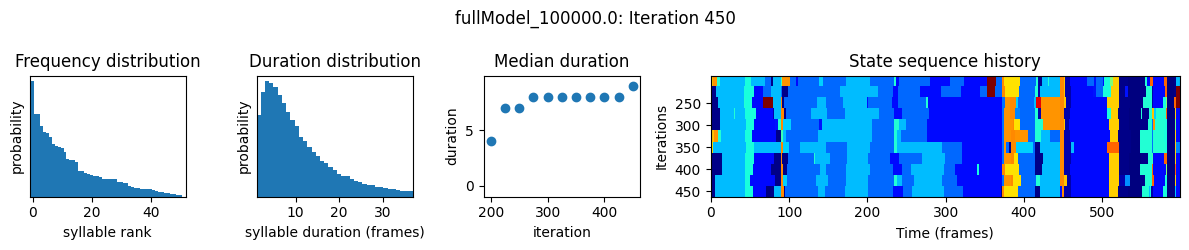

 91%|██████████████████████████████▏  | 275/301 [18:50<01:46,  4.08s/it]

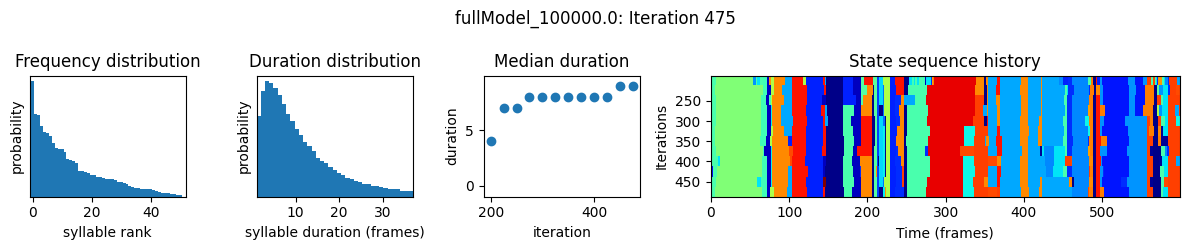

100%|████████████████████████████████▉| 300/301 [20:35<00:04,  4.08s/it]

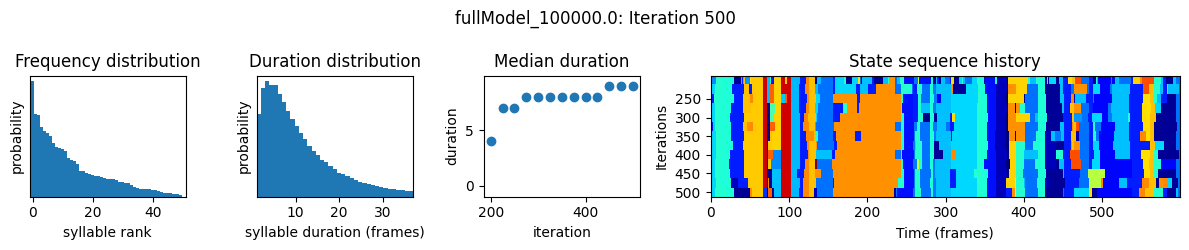

100%|█████████████████████████████████| 301/301 [20:41<00:00,  4.12s/it]


In [33]:
kappa = 1.0e5
model_name = "my_kappa_scan-100000.0"

model_to_fit, data, metadata, current_iter = kpms.load_checkpoint(
    kpmoseq_dir, model_name
)

# modify kappa to maintain the desired syllable time-scale
model_to_fit = kpms.update_hypparams(model_to_fit, kappa = kappa)


# run fitting for an additional 300 iters
model = kpms.fit_model(
    model_to_fit,
    data,
    metadata,
    kpmoseq_dir,
    f"fullModel_{kappa}",
    ar_only=False,
    start_iter=current_iter,
    num_iters=current_iter + 300,
)[0]

## Generating results

In [ ]:
kappa = 1e4
model_name = f"fullModel_{kappa}"

model, data, metadata, current_iter = kpms.load_checkpoint(kpmoseq_dir,
                                                           model_name)
model = kpms.update_hypparams(model, kappa=kappa)

In [11]:
# extract results
results = kpms.extract_results(model, 
                               metadata, 
                               kpmoseq_dir, 
                               model_name)

Saved results to /proj/berzelius-2026-
203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unified
Dataset_topView_KPMS_Resident/fullModel_100000.0/results.h5


Saving trajectory plots to /proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_KPMS_Resident/fullModel_100000.0/trajectory_plots


Generating trajectory plots: 100%|██████| 41/41 [00:23<00:00,  1.75it/s]


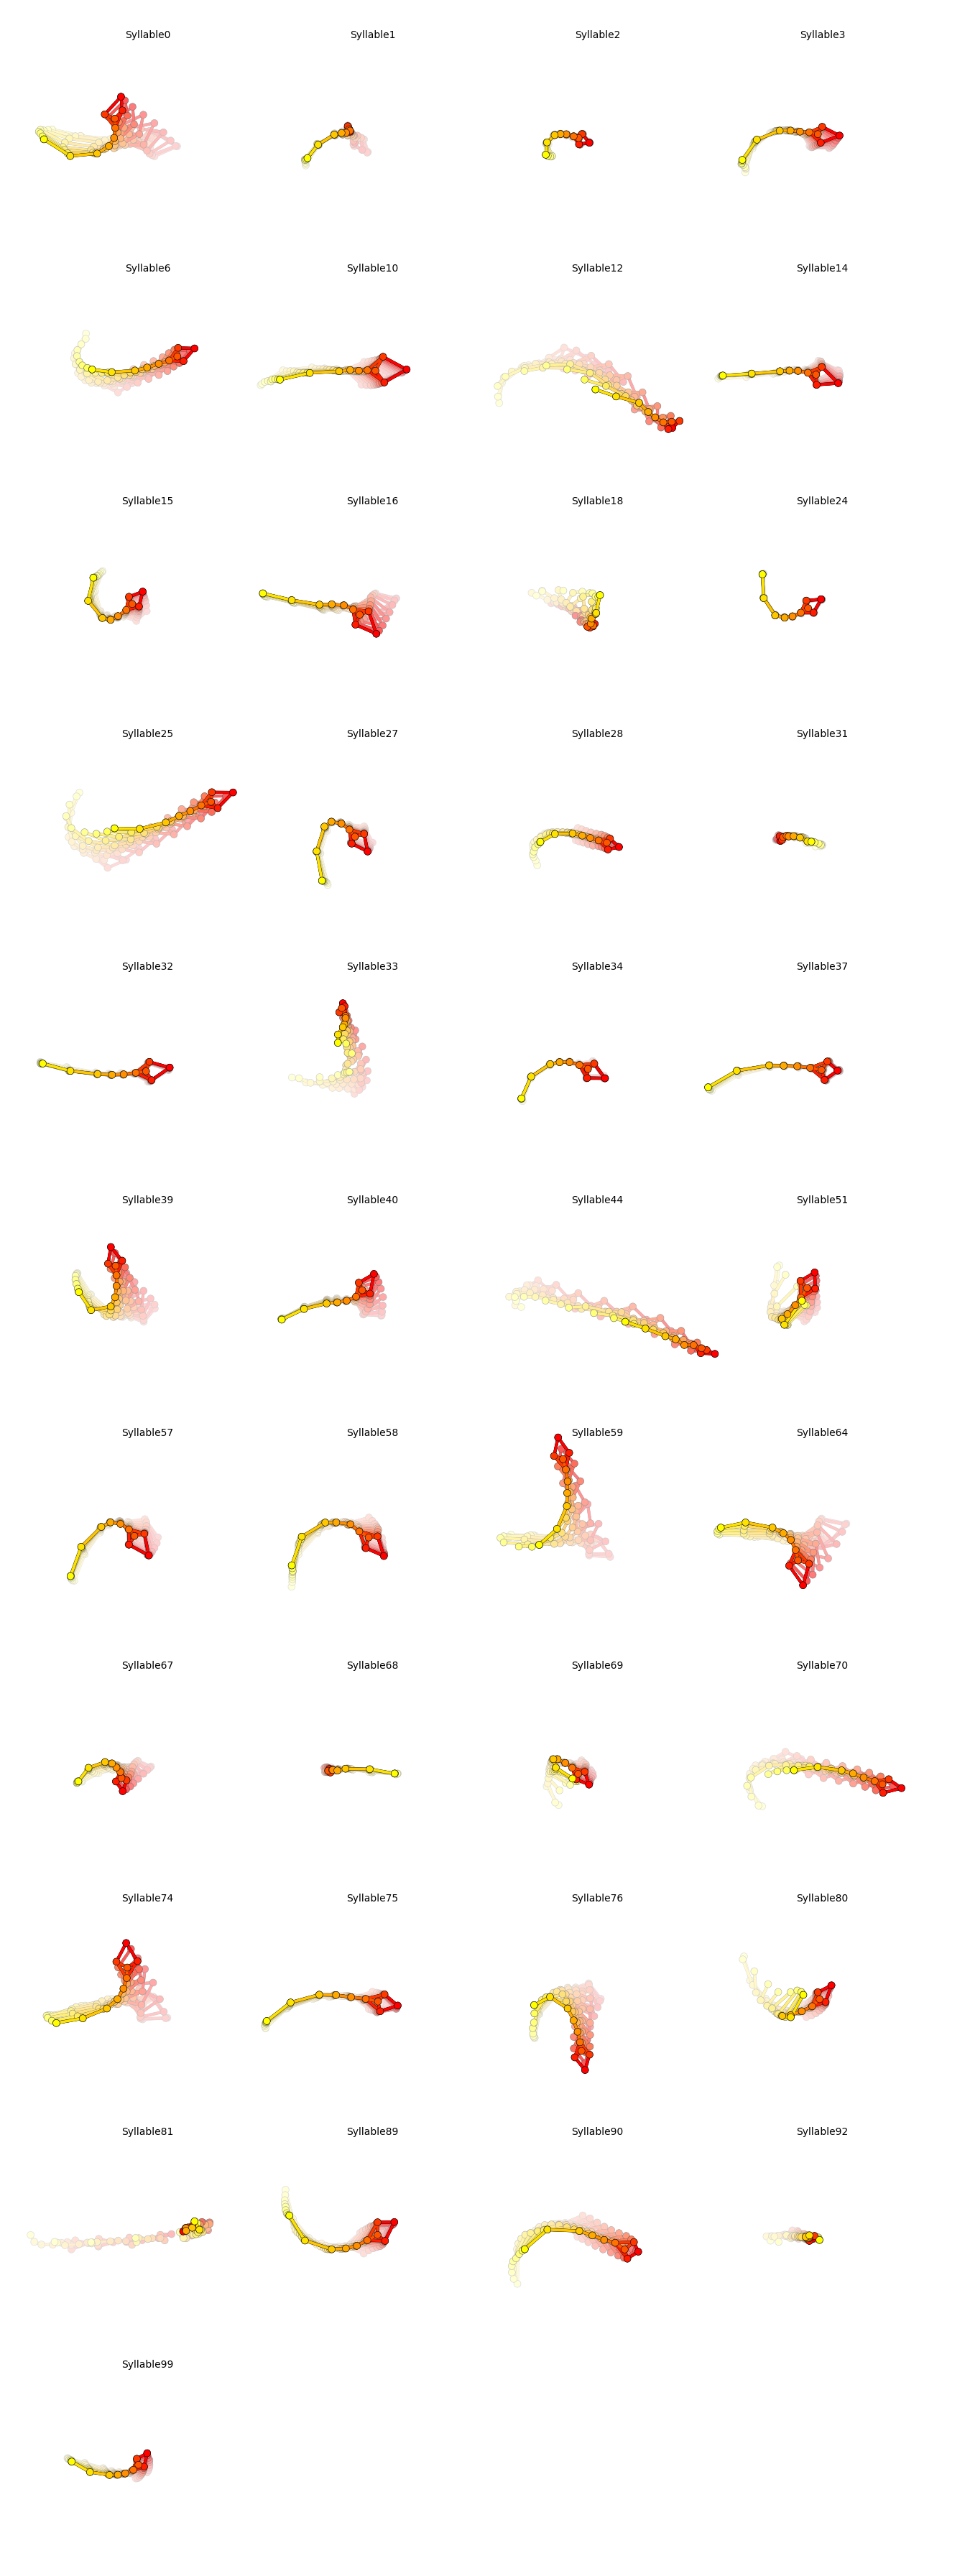

In [12]:
results = kpms.load_results(kpmoseq_dir, model_name)
kpms.generate_trajectory_plots(coordinates, results, kpmoseq_dir, model_name, **config())

In [13]:
kpms.generate_grid_movies(results, kpmoseq_dir, model_name, coordinates=coordinates, **config(), overlay_keypoints=True);


Writing grid movies to /proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_KPMS_Resident/fullModel_100000.0/grid_movies
Using window size of 288 pixels


Generating grid movies: 100%|███████████| 41/41 [02:02<00:00,  2.99s/it]os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.


In [ ]:

kpms.plot_similarity_dendrogram(coordinates, results, kpmoseq_dir, model_name, **config())

In [7]:
h5Dataset = Path("/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/analyzedVideos_unifiedDataset_DLC_singleAnimal_downsampled_10fps")

allData = [str(f) for f in h5Dataset.rglob("*.h5")]
allData

['/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/analyzedVideos_unifiedDataset_DLC_singleAnimal_downsampled_10fps/mouse1010819/topView_DLCtracking_pcutoff_0.8_skeleton/mouse1010819_Day02_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk.h5',
 '/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/analyzedVideos_unifiedDataset_DLC_singleAnimal_downsampled_10fps/mouse1010819/topView_DLCtracking_pcutoff_0.8_skeleton/mouse1010819_Day04_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk.h5',
 '/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/analyzedVideos_unifiedDataset_DLC_singleAnimal_downsampled_10fps/mouse1010819/topView_DLCtracking_pcutoff_0.8_skeleton/mouse1010819_Day05_topView_compDLC_Resnet101_trainingAggression_trainingSessions_topViewFeb3shuffle2_snapshot_best-100_sk.h5',
 '/p

In [8]:
from collections import defaultdict

paths = [
    # your path strings here
]

pattern = re.compile(r"(mouse\d+)_Day0*(\d+)", re.IGNORECASE)

grouped = defaultdict(list)

for path in paths:
    filename = Path(path).name
    match = pattern.search(filename)

    if match:
        mouse_id = match.group(1).lower()
        day_id = int(match.group(2))

        key = (mouse_id, day_id)
        grouped[key].append(path)
    else:
        print(f"Could not extract mouse/day from: {path}")

duplicates = {
    key: matching_paths
    for key, matching_paths in grouped.items()
    if len(matching_paths) > 1
}

if duplicates:
    print("Possible duplicate mouse/day combinations:\n")

    for (mouse_id, day_id), matching_paths in sorted(duplicates.items()):
        print(f"{mouse_id}_Day{day_id:02d} — {len(matching_paths)} files")

        for path in matching_paths:
            print(f"  {Path(path).name}")

        print()
else:
    print("No duplicate mouse/day combinations found.")

No duplicate mouse/day combinations found.


In [31]:
def extract_id(k):
    name = Path(k).name
    m = re.search(r"(mouse\d+).*?(Day\d+)", name, re.IGNORECASE)
    if not m:
        return None
    part = re.search(r"(pt\d+)", name, re.IGNORECASE)
    return f"{m.group(1).lower()}_{m.group(2)}" + (f"_{part.group(1).lower()}" if part else "")

def clean_keys(d):
    new_d = {}
    for k, v in d.items():
        new_key = extract_id(k)
        if new_key is None:
            continue  # or raise error if you prefer
        new_d[new_key] = v
    return new_d

In [32]:
coordinates, confidences, bodyparts = kpms.load_keypoints(allData, 
                                                          "deeplabcut", 
                                                          path_in_name=True)

coordinates = clean_keys(coordinates)
confidences = clean_keys(confidences)

Loading keypoints: 100%|██████████████| 850/850 [00:26<00:00, 31.66it/s]


In [33]:
# Checking for file collisions
groups, nones = defaultdict(list), []
for f in allData:                       # the raw 850
    kid = extract_id(f)
    (nones if kid is None else groups[kid]).append(f)

print("files:", len(allData), "| None:", len(nones), "| unique ids:", len(groups))
for key, members in groups.items():
    if len(members) > 1:
        print(key)
        for m in members:
            print("   ", Path(m).name)

files: 850 | None: 0 | unique ids: 850


In [34]:
coordinates, confidences = kpms.outlier_removal(coordinates,
                                                confidences,
                                                kpmoseq_dir,
                                                overwrite=True,
                                                **config())

data, metadata = kpms.format_data(coordinates, 
                                  confidences, 
                                  **config())

In [35]:
import pickle
import jax
import numpy as np

# Move all JAX arrays from GPU to CPU before saving
checkpoint = {
    "data": jax.tree.map(
        lambda x: np.asarray(jax.device_get(x)) if hasattr(x, "shape") else x,
        data
    ),
    "metadata": metadata,
}

with open("/proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_KPMS_Resident/formattedData_forInference.pkl", "wb") as f:
    pickle.dump(checkpoint, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Saved data and metadata to formatted_data.pkl")

Saved data and metadata to formatted_data.pkl


In [4]:
import pickle
import jax

with open("formatted_data.pkl", "rb") as f:
    checkpoint = pickle.load(f)

data = jax.tree.map(
    lambda x: jax.device_put(x) if hasattr(x, "shape") else x,
    checkpoint["data"]
)

metadata = checkpoint["metadata"]

print("Loaded data and metadata")

Loaded data and metadata


In [40]:
from jax_moseq.utils import set_mixed_map_iters, set_mixed_map_gpus, get_mixed_map_gpus, get_mixed_map_iters

#set_mixed_map_gpus(2)
set_mixed_map_iters(8)  # process the mapped workload in one serial step

print("JAX backend:", jax.default_backend())
print("Visible JAX devices:", jax.device_count())
print("Local JAX devices:", jax.local_device_count())
print("mixed_map GPUs:", get_mixed_map_gpus())
print("mixed_map serial iterations:", get_mixed_map_iters())

for device in jax.devices():
    print(device)

kappa = 1e4
model_name = f"fullModel_{kappa}"

model, prevData, prevMetadata, current_iter = kpms.load_checkpoint(kpmoseq_dir,
                                                           model_name)

JAX backend: gpu
Visible JAX devices: 2
Local JAX devices: 2
mixed_map GPUs: 1
mixed_map serial iterations: 8
cuda:0
cuda:1


In [ ]:
results = kpms.apply_model(model, 
                           data, 
                           metadata, 
                           kpmoseq_dir,
                           model_name=model_name,
                           overwrite = True,
                           parallel_message_passing=True,
                           **config())

Applying model:  26%|███▉           | 131/500 [32:29<1:31:30, 14.88s/it]

In [38]:
len(results.keys())

850

In [15]:
results = kpms.load_results(kpmoseq_dir, model_name)

Saving trajectory plots to /proj/berzelius-2026-203/users/x_migro/data/unifiedDataset_topview_DLC_singleAnimal/unifiedDataset_topView_KPMS_Resident/fullModel_100000.0/trajectory_plots


Generating trajectory plots: 100%|██████| 40/40 [00:22<00:00,  1.75it/s]


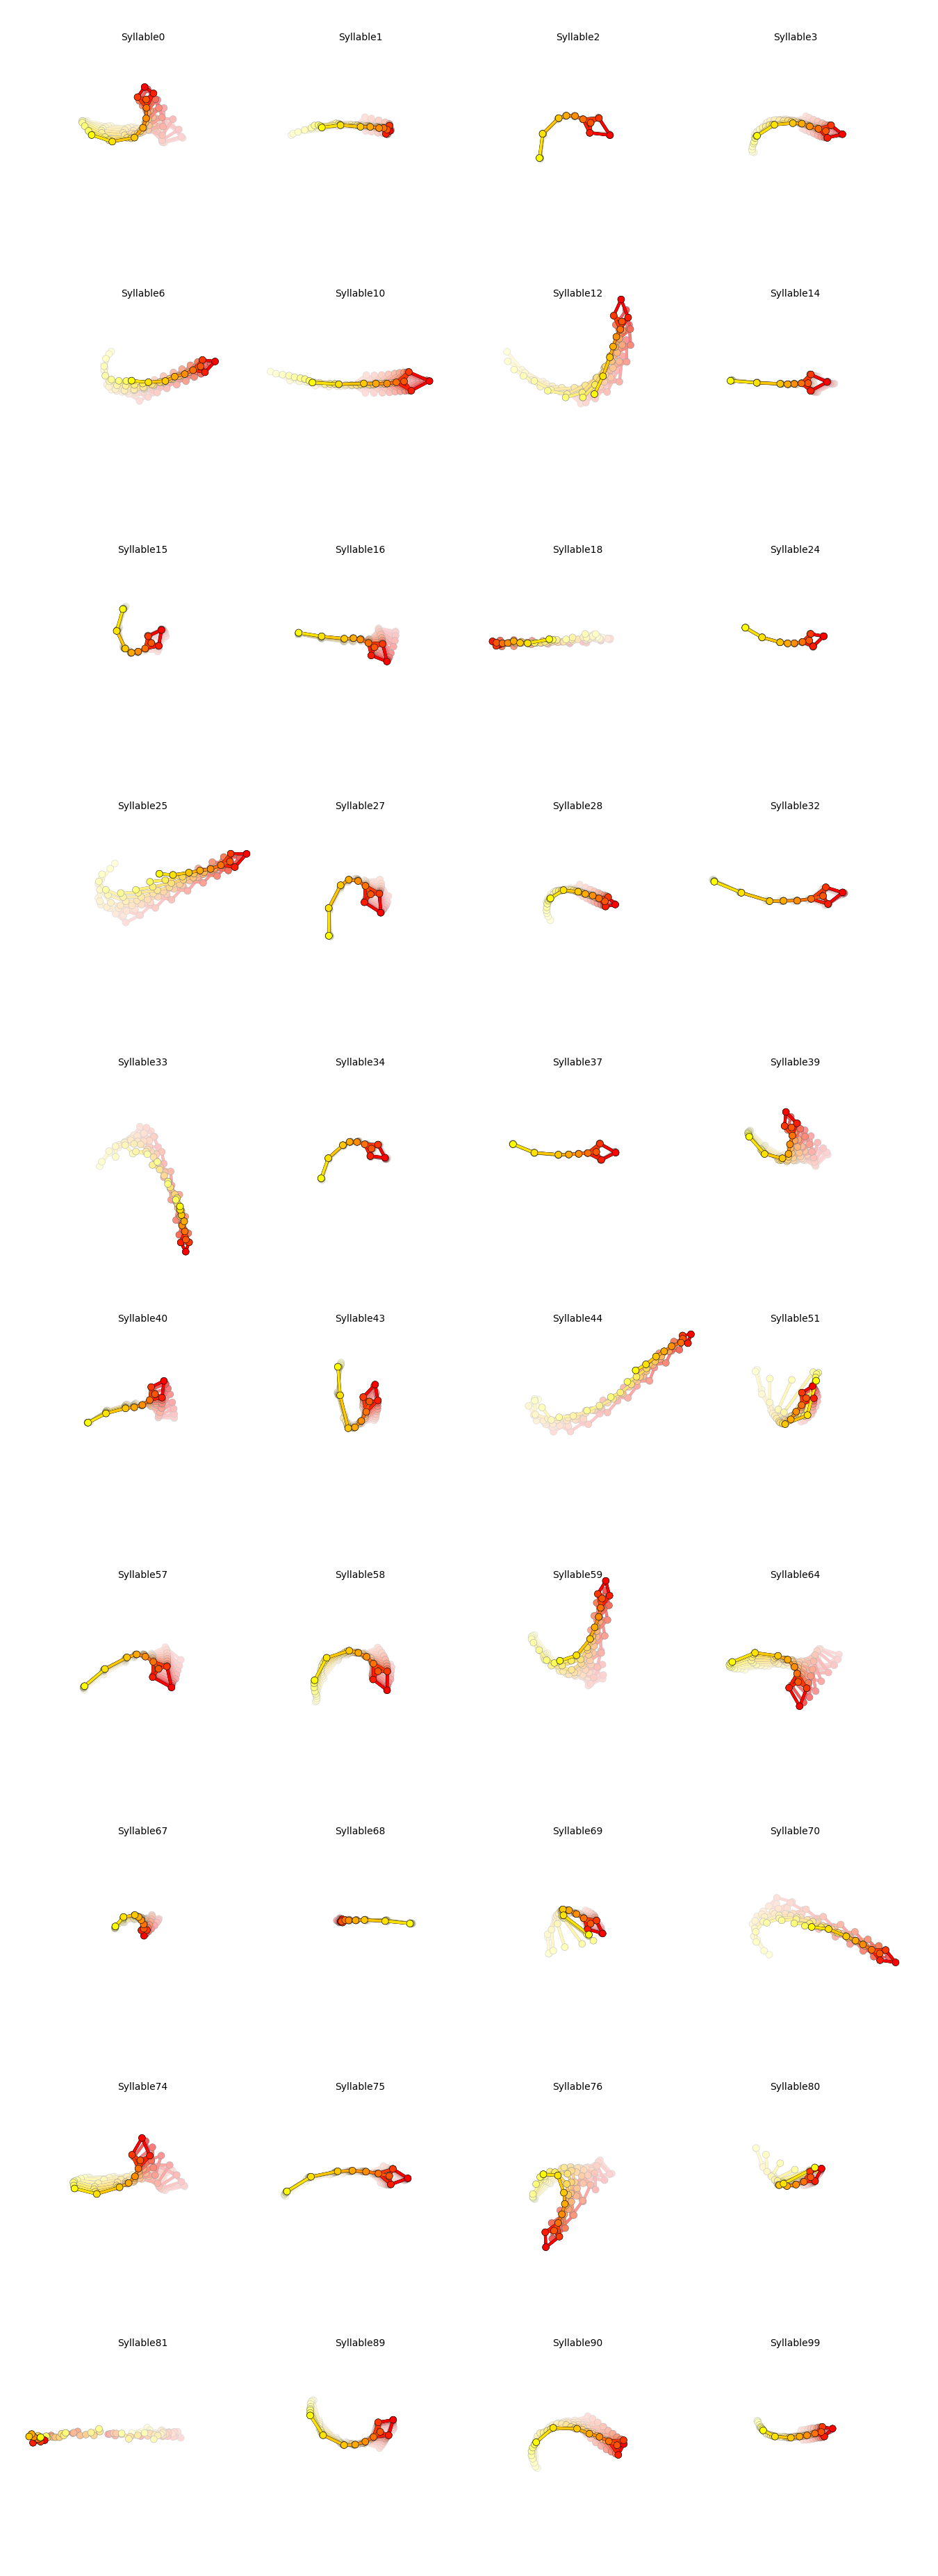

In [39]:
results = kpms.load_results(kpmoseq_dir, model_name)
kpms.generate_trajectory_plots(coordinates, results, kpmoseq_dir, model_name, **config())